(mmm_brand_metrics_long_term)=
# Long-Term Brand Effects in MMMs with Brand Metrics and a Bayesian VARX

Media mix models are very good at one thing: quantifying the short-term sales response to performance media. They are structurally blind to another: the slow accumulation of demand that brand marketing builds through mindset metrics such as awareness and consideration. Brand campaigns rarely trigger immediate purchases, so when brand spend enters an MMM as a regular channel the model usually reports a relatively low direct effect. The brand-driven demand does not disappear, though. It shows up as a slow drift in *base sales*, which the MMM absorbs into its intercept and never attributes to anything.

This is a measurement failure, not a marketing failure, and it has a well-established remedy in the marketing science literature: model the purchase funnel explicitly and let brand marketing act on sales *through* the brand metrics. In this notebook we implement a two-stage Bayesian workflow to recover the full effect:

1. **Stage 1**: fit a PyMC-Marketing {class}`~pymc_marketing.mmm.mmm.MMM` with a **time-varying intercept** (a Hilbert Space Gaussian Process, as in {ref}`mmm_tv_intercept`). The model recovers the short-term channel contributions as usual, and the evolving intercept becomes an explicit estimate of the *dynamic baseline* where brand effects live.
2. **Stage 2**: extract the baseline and model the system {baseline, awareness, consideration} with a **Bayesian vector autoregression with exogenous inputs (VARX)** using the [impulso](https://github.com/thomaspinder/impulso) package, treating brand spend as the exogenous driver. The VARX's *dynamic multiplier* tells us how a unit of brand spend propagates through the funnel into the baseline, week by week, with full posterior uncertainty.

The total return on brand marketing is then the short-term effect (from the MMM, approximately zero here) plus the long-term effect (from the VARX dynamic multiplier). We work with simulated data so we can validate every estimate against a known ground truth.

The approach follows the purchase-journey framework of Cain (2022), and this notebook is a PyMC-Marketing port of the workflow popularized by Ryan O'Sullivan's post [Capturing the long-term causal effect of brand marketing](https://medium.com/@raz1470/capturing-the-long-term-causal-effect-of-brand-marketing-bc577621a627) and by 1749.io's [Measuring Marketing Effectiveness Over the Long-Term](https://1749.io/learn/f/measuring-marketing-effectiveness-over-the-long-term).

> Cain, P. M. (2022). "Modelling short- and long-term marketing effects in the consumer purchase journey." *International Journal of Research in Marketing*, 39(1), 96-116. [doi:10.1016/j.ijresmar.2021.06.006](https://doi.org/10.1016/j.ijresmar.2021.06.006)

```{note}
How does this notebook relate to its siblings?

- {ref}`mmm_var_budget_optimization` also couples an MMM with an impulso VARX, but for *budget allocation* over fast-moving engagement indicators. Here the VARX is used for *measurement*: quantifying long-term brand effects transmitted through mindset metrics into the MMM baseline.
- {ref}`mmm_tv_intercept` introduces the time-varying intercept machinery we use in Stage 1.
- {ref}`mmm_upper_funnel_causal_approach` and {ref}`mmm_funnel_mueffect` handle funnel mediation *inside* a single nested model. The two-stage approach here trades that elegance for the VARX's explicit treatment of persistence, feedback, and long-run dynamics.
```

## Prepare Notebook

In [1]:
import warnings

import arviz as az
import graphviz as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from impulso import (
    VAR,
    VARData,
    adf_test,
    compute_ma_phi,
    johansen_test,
    kpss_test,
    lag_matrices,
    select_lag_order,
)
from impulso.samplers import NUTSSampler
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.hsgp_kwargs import CovFunc, HSGPKwargs
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

seed: int = sum(map(ord, "mmm_brand_metrics_long_term"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/arviz/__init__.py:110: MigrationWarning: arviz.InferenceData is no longer available on the arviz package; ArviZ now uses xarray's DataTree for the same role. See the migration guide: https://python.arviz.org/en/latest/user_guide/migration_guide.html#datatree
  warnings.warn(


## Business Problem and Causal Structure

Picture a direct-to-consumer brand with three and a half years of weekly data. The marketing team runs two always-on performance channels, `x1` (search-like) and `x2` (social-like), and a few times per year it launches an eight-week TV brand campaign, `brand_spend`. A weekly brand-tracking survey measures `awareness` and `consideration`. All monetary quantities are expressed in units of \$10k, so any ratio of incremental sales to spend is a unit-free ROI.

Our structural assumptions are summarized in the causal graph below. The performance channels act directly on sales with the usual adstock and saturation dynamics. Brand spend has **no direct edge to sales**: its entire effect flows through the funnel, lifting awareness, which feeds consideration, which drives *base sales* (the non-media demand level). Each funnel variable is persistent, so a brand campaign keeps paying back long after it ends.

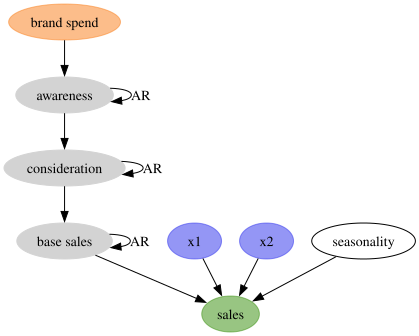

In [2]:
g = gr.Digraph()
g.node("brand spend", color="#fa7c1780", style="filled")
g.node("awareness", color="lightgray", style="filled")
g.node("consideration", color="lightgray", style="filled")
g.node("base sales", color="lightgray", style="filled")
g.node("x1", color="#2a2eec80", style="filled")
g.node("x2", color="#2a2eec80", style="filled")
g.node("seasonality")
g.node("sales", color="#328c0680", style="filled")
g.edge("brand spend", "awareness")
g.edge("awareness", "awareness", label="AR")
g.edge("awareness", "consideration")
g.edge("consideration", "consideration", label="AR")
g.edge("consideration", "base sales")
g.edge("base sales", "base sales", label="AR")
g.edge("base sales", "sales")
g.edge("x1", "sales")
g.edge("x2", "sales")
g.edge("seasonality", "sales")
g

Because there is no direct `brand spend -> sales` edge, a regression of sales on (transformed) brand spend estimates the *direct* short-term effect, which is genuinely zero. The *total* effect is the one the CMO cares about, and it lives on the mediated path. Our measurement strategy therefore has two stages:

| Stage | Model | Inputs | Output |
|---|---|---|---|
| 1 | MMM with time-varying intercept | sales, `x1`, `x2` | short-term contributions + dynamic baseline |
| 2 | Bayesian VARX (impulso) | baseline, `awareness`, `consideration`; `brand_spend` exogenous | dynamic multiplier of brand spend on the baseline |

## Simulate Data with a PyMC Generative Model

We simulate the data with PyMC models, following the pattern of the {ref}`mmm_data_generator` notebook: draw the covariates from a small PyMC model, then build a *generator* MMM on a dummy target, fix its parameters at true values with PyMC's {func}`~pymc.model.transform.conditioning.do` operator, and take a single prior predictive draw as the observed data. Everything downstream can then be validated against the stored ground truth.

We simulate `l_max` extra initial weeks and drop them afterwards, so that adstock carryover and the funnel recursions are properly warmed up.

In [3]:
l_max = 8
n_weeks = 182 + l_max

dates = pd.date_range(start="2021-01-04", periods=n_weeks, freq="W-MON")

coords = {"date": dates}

### Performance media spends

Two correlated, always-on channels drawn from a latent multivariate normal pushed through a softplus (so spends are positive), exactly as in the data generator notebook. The latent scale is chosen so that weekly spend sweeps a wide dynamic range, from near zero to well above the typical level. This is not just cosmetic: a saturation curve is only identifiable if the data visit both its toe and its shoulder, and always-on spend confined to a narrow band produces a ridge between the saturation parameters that no sampler can resolve.

In [4]:
spend_coords = {"date": dates, "channel_dim": ["x1", "x2"]}

spend_mu = np.array([-0.2, -0.9])
spend_sd = np.array([0.9, 1.1])
spend_corr = 0.4
spend_cov = (
    np.diag(spend_sd)
    @ np.array([[1.0, spend_corr], [spend_corr, 1.0]])
    @ np.diag(spend_sd)
)

with pm.Model(coords=spend_coords) as spend_model:
    spend_raw = pm.MvNormal(
        "spend_raw",
        mu=spend_mu,
        cov=spend_cov,
        dims=("date", "channel_dim"),
    )
    spend = pm.Deterministic(
        "spend", pt.softplus(spend_raw), dims=("date", "channel_dim")
    )

spend_draw = pm.draw(spend_model.spend, draws=1, random_seed=rng)
x1, x2 = spend_draw[:, 0], spend_draw[:, 1]

### Brand campaign flights

Brand spend is not drawn from a distribution: it is a *planned* schedule of four eight-week flights. This is deliberate and it matters for Stage 2. Because the flight calendar is set by the marketing team and does not react to weekly demand shocks, brand spend is exogenous to the funnel system, which is exactly the assumption the VARX dynamic multiplier needs to have a causal reading.

The flight start weeks are chosen to be irregular, so that the campaign pattern does not accidentally align with the yearly seasonal cycle (we verify the correlation is negligible below).

In [5]:
flight_starts = [7, 72, 99, 124]

brand_spend = np.zeros(n_weeks)
for start in flight_starts:
    s = start + l_max
    brand_spend[s : s + 8] = rng.uniform(0.9, 1.1, size=8)

seasonal_proxy = np.sin(2 * np.pi * np.arange(n_weeks) / 52.18)
corr_check = np.corrcoef(brand_spend, seasonal_proxy)[0, 1]
np.testing.assert_array_less(np.abs(corr_check), 0.1)
print(f"corr(brand flights, yearly cycle) = {corr_check:.3f}")

corr(brand flights, yearly cycle) = 0.007


### Brand funnel: awareness, consideration, and base sales

The funnel is a small structural time-series model, written as a PyMC model with a `pytensor.scan` recursion:

$$
\begin{aligned}
a_t &= \mu_a (1 - \rho_a) + \rho_a a_{t-1} + \gamma \, \text{brand}_t + \varepsilon^a_t \\
c_t &= \mu_c (1 - \rho_c) + \rho_c c_{t-1} + \delta \, a_{t-1} + \varepsilon^c_t \\
b_t &= b_0 (1 - \rho_b) + \rho_b b_{t-1} + \beta_c \, c_{t-1} + \varepsilon^b_t
\end{aligned}
$$

where $a$ is awareness, $c$ is consideration, and $b$ is base sales. Each equation is a stable AR(1) fed by the level above it in the funnel, so a brand campaign lifts awareness within the flight, consideration follows with a lag, and base sales drift upward over the following months. The survey we observe adds a little measurement noise on top of the latent awareness and consideration states.

A few parameter choices worth highlighting:

- $\rho_a = 0.90$ gives awareness a half-life of about 6.6 weeks: clearly persistent, but the response is mostly realized within a half-year evaluation window. Values very close to 1 make the long-run effect take years to materialize and are also harder to estimate in a short sample.
- Base sales has its own AR coefficient $\rho_b$ and innovation. This represents sales inertia (habit, repeat purchase) and it also matters statistically: if base sales were a deterministic function of consideration, the Stage-2 system {baseline, awareness, consideration} would be perfectly collinear by construction.

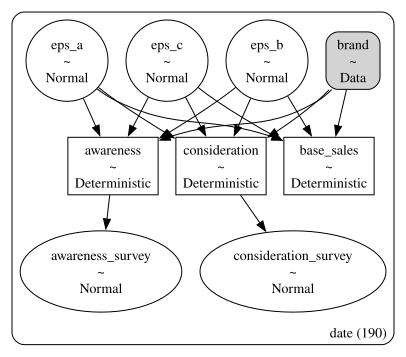

In [6]:
rho_a, gamma, mu_a, sigma_a = 0.90, 0.25, 1.0, 0.04
rho_c, delta, mu_c, sigma_c = 0.80, 0.4, 0.5, 0.03
rho_b, beta_c, base_ss, sigma_b = 0.5, 0.6, 3.5, 0.04
survey_sigma = 0.03

a_ss = mu_a
c_ss = mu_c + delta * a_ss / (1 - rho_c)
b0 = base_ss - beta_c * c_ss / (1 - rho_b)

with pm.Model(coords=coords) as funnel_model:
    brand = pm.Data("brand", brand_spend, dims="date")
    eps_a = pm.Normal("eps_a", mu=0, sigma=sigma_a, dims="date")
    eps_c = pm.Normal("eps_c", mu=0, sigma=sigma_c, dims="date")
    eps_b = pm.Normal("eps_b", mu=0, sigma=sigma_b, dims="date")

    def step(brand_t, ea_t, ec_t, eb_t, a_prev, c_prev, b_prev):
        a_t = mu_a * (1 - rho_a) + rho_a * a_prev + gamma * brand_t + ea_t
        c_t = mu_c * (1 - rho_c) + rho_c * c_prev + delta * a_prev + ec_t
        b_t = b0 * (1 - rho_b) + rho_b * b_prev + beta_c * c_prev + eb_t
        return a_t, c_t, b_t

    (a_seq, c_seq, b_seq) = pytensor.scan(
        fn=step,
        sequences=[brand, eps_a, eps_c, eps_b],
        outputs_info=[
            pt.constant(np.float64(a_ss)),
            pt.constant(np.float64(c_ss)),
            pt.constant(np.float64(base_ss)),
        ],
        return_updates=False,
    )
    awareness = pm.Deterministic("awareness", a_seq, dims="date")
    consideration = pm.Deterministic("consideration", c_seq, dims="date")
    base_sales = pm.Deterministic("base_sales", b_seq, dims="date")

    awareness_survey = pm.Normal(
        "awareness_survey", mu=awareness, sigma=survey_sigma, dims="date"
    )
    consideration_survey = pm.Normal(
        "consideration_survey", mu=consideration, sigma=survey_sigma, dims="date"
    )

pm.model_to_graphviz(funnel_model)

In [7]:
(
    awareness_true,
    consideration_true,
    base_sales_true,
    awareness_obs,
    consideration_obs,
) = pm.draw(
    [
        funnel_model.awareness,
        funnel_model.consideration,
        funnel_model.base_sales,
        funnel_model.awareness_survey,
        funnel_model.consideration_survey,
    ],
    draws=1,
    random_seed=rng,
)

### Sales: a generator MMM with `do` interventions

For the sales equation we reuse the {class}`~pymc_marketing.mmm.mmm.MMM` class itself as the data generator, so the short-term media effects follow exactly the adstock and saturation transformations the model will later estimate. The trick, borrowed from the data generator notebook, is to build the model on a dummy target of ones (which makes the internal max-abs scaling the identity) and then use {func}`pymc.do` to fix every parameter at its true value. Because the generator uses `time_varying_intercept=True`, the `intercept_contribution` variable has a `date` dimension, and we can intervene on it with the *entire true base sales path* from the funnel model above. A single prior predictive draw then produces the observed sales along with the true channel contributions.

In [8]:
intercept_tvp_config = HSGPKwargs(
    m=50, L=None, eta_lam=1.0, ls_mu=5.0, ls_sigma=10.0, cov_func=CovFunc.Matern52
)

mmm_df = pd.DataFrame({"date": dates, "x1": x1, "x2": x2, "y_dummy": np.ones(n_weeks)})

mmm_generator = MMM(
    date_column="date",
    target_column="y_dummy",
    channel_columns=["x1", "x2"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config={"intercept_tvp_config": intercept_tvp_config},
)

X_generator = mmm_df.drop(columns=["y_dummy"])
mmm_generator.build_model(X_generator, mmm_df["y_dummy"])
mmm_generator.add_original_scale_contribution_variable(
    var=["channel_contribution", "intercept_contribution", "y"]
)

adstock_alpha_true = np.array([0.4, 0.2])
saturation_beta_true = np.array([1.2, 0.8])
saturation_lam_true = np.array([2.5, 2.0])
gamma_fourier_true = np.array([0.15, -0.1, 0.1, 0.05])
y_sigma_true = 0.12

mmm_generator.model = do(
    mmm_generator.model,
    {
        "intercept_contribution": base_sales_true,
        "adstock_alpha": adstock_alpha_true,
        "saturation_beta": saturation_beta_true,
        "saturation_lam": saturation_lam_true,
        "gamma_fourier": gamma_fourier_true,
        "y_sigma": y_sigma_true,
    },
)

with mmm_generator.model:
    idata_generator = pm.sample_prior_predictive(
        draws=1,
        var_names=[
            "y_original_scale",
            "channel_contribution_original_scale",
            "fourier_contribution",
        ],
        random_seed=rng,
    )

y_obs = idata_generator["prior"]["y_original_scale"].sel(chain=0, draw=0).to_numpy()
channel_contribution_true = (
    idata_generator["prior"]["channel_contribution_original_scale"]
    .sel(chain=0, draw=0)
    .to_numpy()
)
fourier_true = (
    idata_generator["prior"]["fourier_contribution"].sel(chain=0, draw=0).to_numpy()
)

Sampling: [y]


Finally we assemble the observed dataset (what an analyst would actually receive) and a separate truth table (what we keep for validation only), dropping the warm-up weeks.

In [9]:
df = (
    pd.DataFrame(
        {
            "date": dates,
            "x1": x1,
            "x2": x2,
            "brand_spend": brand_spend,
            "awareness": awareness_obs,
            "consideration": consideration_obs,
            "y": y_obs,
        }
    )
    .tail(-l_max)
    .reset_index(drop=True)
)

truth_df = (
    pd.DataFrame(
        {
            "date": dates,
            "base_sales": base_sales_true,
            "awareness_latent": awareness_true,
            "consideration_latent": consideration_true,
            "x1_contribution": channel_contribution_true[:, 0],
            "x2_contribution": channel_contribution_true[:, 1],
            "fourier": fourier_true.sum(axis=-1),
        }
    )
    .tail(-l_max)
    .reset_index(drop=True)
)

n_obs = len(df)

df.head()

,date,x1,x2,brand_spend,awareness,consideration,y
0,2021-03-01,0.437559,0.374785,0.0,0.989339,2.309587,3.863143
1,2021-03-08,0.152899,0.142339,0.0,0.979903,2.383373,3.649521
2,2021-03-15,1.008619,0.591242,0.0,1.014202,2.369849,3.850973
3,2021-03-22,0.299215,0.119386,0.0,1.056714,2.502459,3.794218
4,2021-03-29,0.634628,0.254614,0.0,1.010331,2.469223,3.919864


In [10]:
# The Stage-1 comparison of `saturation_lam` against the generator only holds if
# the max-abs scaling is the same in both. The generator sees the full spend
# series; Stage 1 sees the frame trimmed by `l_max`. They match only if each
# channel's maximum falls outside the warm-up weeks, so we check it explicitly.
np.testing.assert_allclose(
    df[["x1", "x2"]].max().to_numpy(),
    np.array([x1, x2]).max(axis=1),
    err_msg=(
        "trimmed frame max-abs scale differs from the generator; "
        "saturation_lam is no longer directly comparable across the two models"
    ),
)

### Ground truth: the true dynamic multiplier of brand spend

Before fitting anything, let us compute the quantity we will try to recover. Propagating a one-unit, one-week pulse of brand spend through the noise-free funnel recursions gives the true impulse response of base sales, and its cumulative sum is the true *cumulative dynamic multiplier*: the total incremental base sales generated within $h$ weeks per unit of brand spend.

The infinite-horizon limit has a closed form, $\beta_c \delta \gamma / \left[(1-\rho_a)(1-\rho_c)(1-\rho_b)\right] = 6.0$. We will quote results at a 26-week horizon (27 weekly responses, $h = 0, \dots, 26$, including the impulse week), where about 86% of the long-run effect has been realized. The choice of horizon is an accounting convention, just like a payback window in finance, and it should be stated explicitly in any real analysis.

In [11]:
horizon = 26

impulse_a = np.zeros(horizon + 1)
impulse_c = np.zeros(horizon + 1)
impulse_b = np.zeros(horizon + 1)
impulse_a[0] = gamma

for h in range(1, horizon + 1):
    impulse_a[h] = rho_a * impulse_a[h - 1]
    impulse_c[h] = rho_c * impulse_c[h - 1] + delta * impulse_a[h - 1]
    impulse_b[h] = rho_b * impulse_b[h - 1] + beta_c * impulse_c[h - 1]

true_cum_multiplier = np.cumsum(impulse_b)
true_long_term_roi = true_cum_multiplier[-1]
asymptote = beta_c * delta * gamma / ((1 - rho_a) * (1 - rho_c) * (1 - rho_b))

print(f"true cumulative multiplier at h={horizon}: {true_long_term_roi:.2f}")
print(f"infinite-horizon asymptote: {asymptote:.2f}")
print(f"share realized within {horizon} weeks: {true_long_term_roi / asymptote:.1%}")

true_roi_x1 = truth_df["x1_contribution"].sum() / df["x1"].sum()
true_roi_x2 = truth_df["x2_contribution"].sum() / df["x2"].sum()
print(f"true short-term ROI x1: {true_roi_x1:.2f}, x2: {true_roi_x2:.2f}")

true cumulative multiplier at h=26: 5.15
infinite-horizon asymptote: 6.00
share realized within 26 weeks: 85.9%
true short-term ROI x1: 0.53, x2: 0.34


### A first look at the data

The plots below tell the story we will need to recover statistically: awareness climbs during every flight and decays afterwards, consideration follows more slowly, and sales drift upward on top of the short-term media noise.

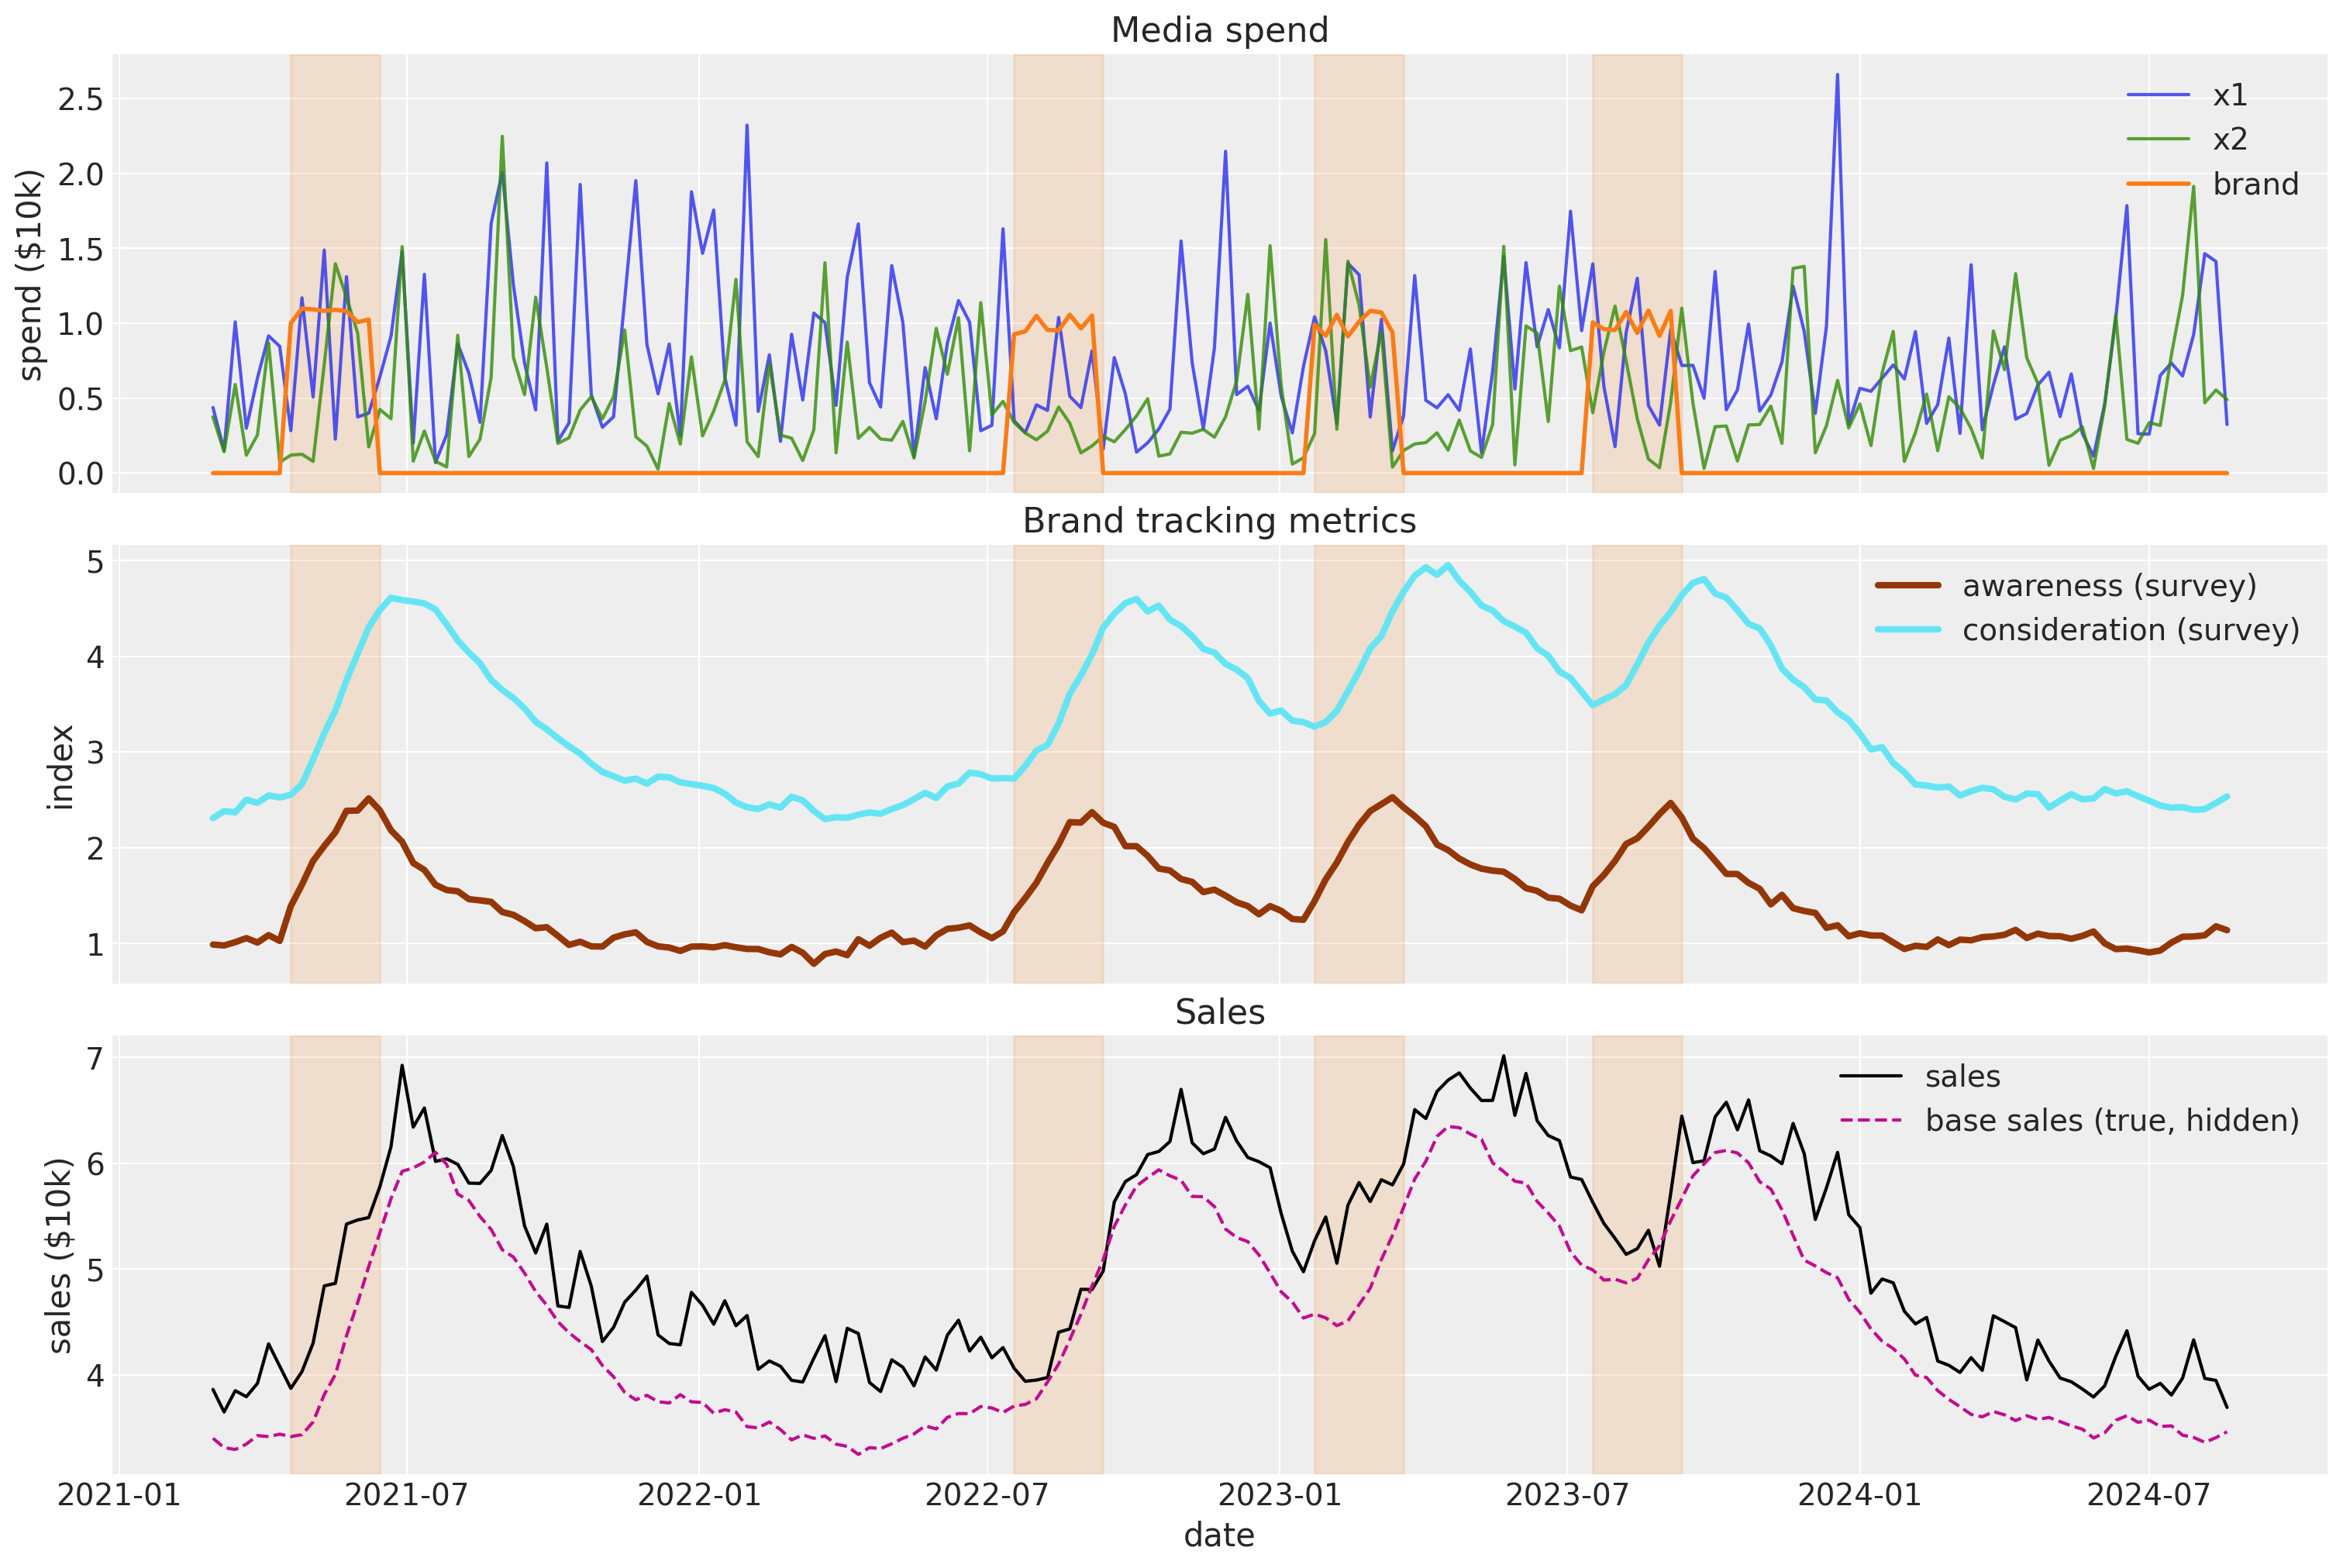

In [12]:
def shade_flights(ax):
    for start in flight_starts:
        left = dates[start + l_max]
        right = dates[min(start + l_max + 8, n_weeks - 1)]
        ax.axvspan(left, right, color="C1", alpha=0.15)


fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    sharey=False,
    figsize=(15, 10),
    layout="constrained",
)
axes[0].plot(df["date"], df["x1"], color="C0", alpha=0.8, label="x1")
axes[0].plot(df["date"], df["x2"], color="C2", alpha=0.8, label="x2")
axes[0].plot(df["date"], df["brand_spend"], color="C1", linewidth=2, label="brand")
shade_flights(axes[0])
axes[0].legend(loc="upper right")
axes[0].set(title="Media spend", ylabel="spend ($10k)")

axes[1].plot(
    df["date"],
    df["awareness"],
    color="C4",
    linewidth=3,
    label="awareness (survey)",
)
axes[1].plot(
    df["date"],
    df["consideration"],
    color="C5",
    linewidth=3,
    label="consideration (survey)",
)
shade_flights(axes[1])
axes[1].legend(loc="upper right")
axes[1].set(title="Brand tracking metrics", ylabel="index")

axes[2].plot(df["date"], df["y"], color="black", label="sales")
axes[2].plot(
    truth_df["date"],
    truth_df["base_sales"],
    color="C3",
    linestyle="--",
    label="base sales (true, hidden)",
)
shade_flights(axes[2])
axes[2].legend(loc="upper right")
axes[2].set(title="Sales", ylabel="sales ($10k)", xlabel="date");

## The Naive Approach: Brand Spend as a Regular MMM Channel

What most teams do first is add brand spend to the MMM as a third channel. Let us do exactly that, with a time-varying intercept and the same core specification we will use later, and see what happens.

Two remarks on the specification. First, the `saturation_beta` prior scales with each channel's share of total spend. This prior is load-bearing in a model with a flexible intercept: without it, the sampler can trade the baseline against a channel contribution and the posterior becomes badly multimodal. Second, we always run four chains, so that any residual multimodality shows up in the diagnostics rather than silently biasing one chain's answer.

In [13]:
sampler_config = {
    "tune": 2_000,
    "draws": 1_000,
    "chains": 4,
    "nuts_sampler": "nutpie",
    "target_accept": 0.95,
    "random_seed": seed,
}

naive_channels = ["x1", "x2", "brand_spend"]
cost_share_naive = xr.DataArray(
    df[naive_channels].sum() / df[naive_channels].sum().sum(),
    dims="channel",
)

model_config_naive = {
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=2)),
    "gamma_fourier": Prior("Normal", mu=0, sigma=2, dims="fourier_mode"),
    "intercept_tvp_config": intercept_tvp_config,
    "adstock_alpha": Prior("Beta", alpha=2, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", mu=2, sigma=0.5, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=cost_share_naive, dims="channel"),
}

In [14]:
%%time
mmm_naive = MMM(
    date_column="date",
    target_column="y",
    channel_columns=naive_channels,
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config=model_config_naive,
)

X_naive = df[["date", *naive_channels]]
y = df["y"]

mmm_naive.build_model(X_naive, y)
mmm_naive.add_original_scale_contribution_variable(
    var=["channel_contribution", "intercept_contribution"]
)
_ = mmm_naive.fit(X_naive, y, **sampler_config)

NUTS[nutpie]: [intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, y_sigma]


Output()

Output()

CPU times: user 2min 34s, sys: 1.75 s, total: 2min 36s
Wall time: 43.8 s


In [15]:
az.diagnose(mmm_naive.idata)

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


False

In [16]:
az.summary(
    mmm_naive.idata,
    var_names=["saturation_beta", "adstock_alpha", "saturation_lam"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
saturation_beta[x1],0.28,0.073,0.19,0.41,4252,2945,1.00,0.0012,0.0012
saturation_beta[x2],0.1354,0.0343,0.092,0.2,6485,2845,1.00,0.00048,0.00047
saturation_beta[brand_spend],0.0074,0.01,0.00034,0.023,3479,3326,1.00,0.00019,0.00072
adstock_alpha[x1],0.506,0.069,0.39,0.61,4087,3395,1.00,0.0011,0.00077
adstock_alpha[x2],0.216,0.086,0.087,0.36,4400,3251,1.00,0.0013,0.00094
adstock_alpha[brand_spend],0.479,0.224,0.13,0.85,3635,2976,1.00,0.0037,0.002
saturation_lam[x1],1.88,0.435,1.2,2.6,4842,3315,1.00,0.0062,0.0043
saturation_lam[x2],1.93,0.477,1.2,2.7,6069,2646,1.00,0.006,0.0045
saturation_lam[brand_spend],1.93,0.51,1.2,2.8,3647,2251,1.00,0.0084,0.0064


The incremental ROI per channel comes from the {attr}`~pymc_marketing.mmm.mmm.MMM.incrementality` namespace, which computes counterfactual contributions with proper adstock carryover handling. We visualize the posterior ROI of each channel as a forest plot (median, 50% and 94% intervals), with the *true direct* ROI of each channel marked by a black diamond — recall that for brand spend the true direct effect is exactly zero by construction.

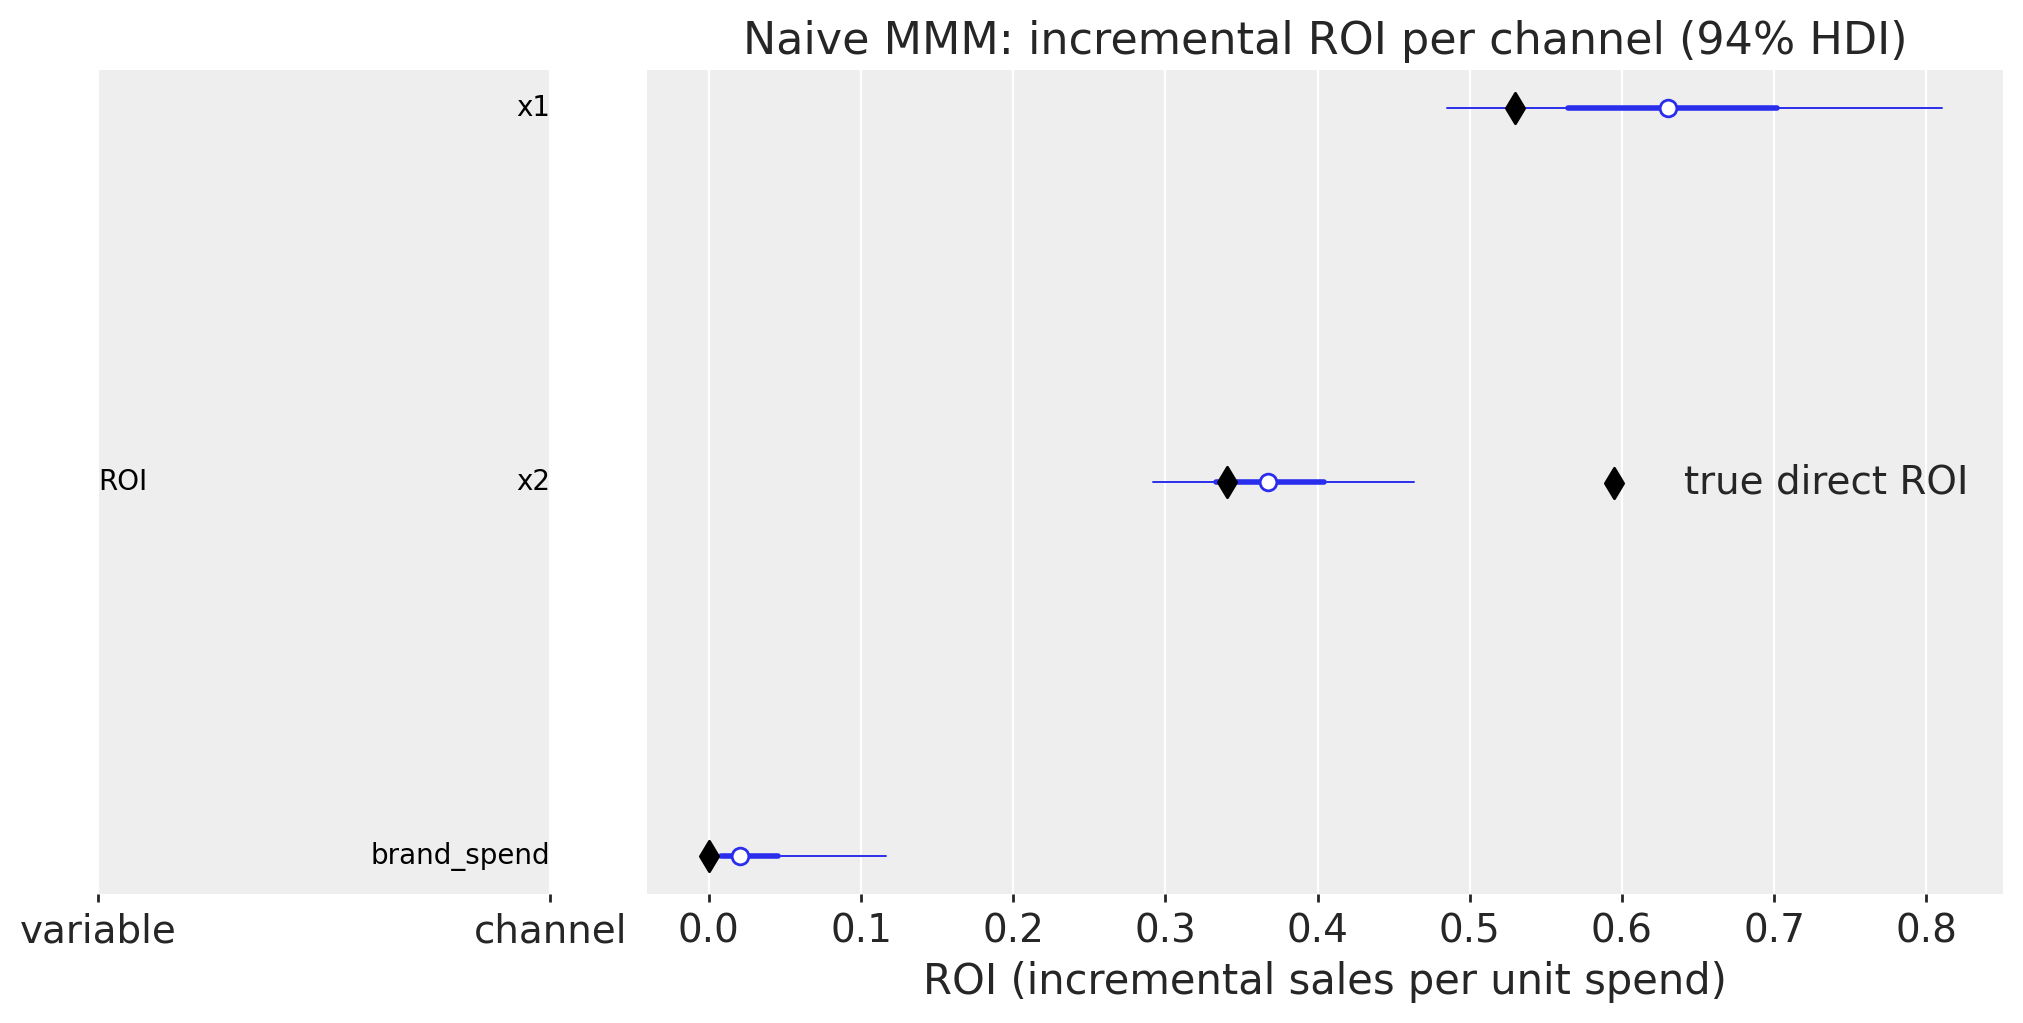

In [17]:
roi_naive = mmm_naive.incrementality.contribution_over_spend(
    frequency="all_time"
).rename("roi")

pc = az.plot_forest(
    xr.Dataset({"ROI": roi_naive}),
    combined=True,
    point_estimate="median",
    figure_kwargs={"figsize": (10, 5)},
)
ax = pc.viz["/"]["plot"].sel(column="forest").item()
for channel, true_roi in zip(
    naive_channels, [true_roi_x1, true_roi_x2, 0.0], strict=True
):
    y_pos = (
        pc.viz["point_estimate"]["ROI"].sel(channel=channel).item().get_offsets()[0, 1]
    )
    ax.scatter(
        true_roi,
        y_pos,
        color="black",
        marker="d",
        s=60,
        zorder=5,
        label="true direct ROI" if channel == "x1" else None,
    )
ax.legend(loc="center right")
ax.set(
    title="Naive MMM: incremental ROI per channel (94% HDI)",
    xlabel="ROI (incremental sales per unit spend)",
);

The naive model reports an ROI of essentially zero for brand spend: with no short-term signal to latch onto, the brand response parameters collapse toward their priors (`saturation_beta[brand_spend]` sits right at zero) and the channel's contribution to sales is negligible. Both performance channels recover their true short-term ROIs, marked by the black diamonds.

The `x1` row carries the most posterior uncertainty of the three channels, and it is worth understanding why. The naive specification hands the sampler three flexible components that compete for the same variation — the `x1` saturation curve, a spurious brand channel with no real effect, and the GP baseline — so `saturation_beta[x1]` and `saturation_lam[x1]` trade off along a ridge: a moderate `lam` gives a nearly linear response over the observed spend range, while a larger `lam` with a larger `beta` gives a high-ceiling curve. Left unchecked this ridge stalls the sampler; a tighter `saturation_lam` prior and a longer warmup keep it identified, so the diagnostics above are clean (`az.diagnose` reports no problems and every $\hat{R}$ is 1.0). The residual spread on `x1` is then honest uncertainty from asking one channel to share short-term variation with two other flexible components — and Stage 1 below, which drops the spurious brand channel, tightens it.

Here is the uncomfortable part: **the model is right** about brand. The direct short-term effect of brand marketing *is* zero in our simulation. And yet this number is useless, and dangerous, as an answer to "what did the brand campaigns do for the business?", because the entire brand effect went into the time-varying intercept. If this ROI figure were taken at face value, the brand budget would be cut. To answer the CMO's actual question we need to follow the effect into the baseline, which is what the two-stage workflow does.

## Stage 1: MMM with a Time-Varying Baseline

We now fit the measurement MMM with only the performance channels, following the causal graph, where brand spend has no direct edge to sales. A word of caution on this step: here we *know* the graph because we simulated it, so dropping brand is unambiguously correct. With real data you do not, and "the naive model estimated a near-zero direct effect, so I will now assume it is exactly zero" is circular. If brand does carry a genuine direct short-term effect, excluding it from Stage 1 pushes that effect into the baseline, where Stage 2 re-credits it through the funnel path; the total stays roughly right but the short-versus-long decomposition is wrong. The safer default on real data is to keep brand in Stage 1 and, in Stage 2, credit brand only through the baseline path rather than any residual direct term. Excluding brand here also protects us from double counting when we credit it through the baseline in Stage 2.

The time-varying intercept is a Hilbert Space Gaussian Process approximation, configured through {class}`~pymc_marketing.hsgp_kwargs.HSGPKwargs` as in {ref}`mmm_roas` and {ref}`mmm_tv_intercept`.

```{note}
The HSGP time-varying intercept is an *in-sample decomposition* device: out of sample it reverts to the prior mean. This workflow is therefore for measurement, not for forecasting the baseline. Anything else missing from the model (price changes, distribution, promotions) also lands in the baseline, so with real data make sure such drivers are either included as controls in Stage 1 or as variables in Stage 2, lest the VARX misattribute their effect to brand.
```

In [18]:
channels = ["x1", "x2"]
cost_share = xr.DataArray(
    df[channels].sum() / df[channels].sum().sum(),
    dims="channel",
)

model_config = {
    "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=2)),
    "gamma_fourier": Prior("Normal", mu=0, sigma=2, dims="fourier_mode"),
    "intercept_tvp_config": intercept_tvp_config,
    "adstock_alpha": Prior("Beta", alpha=2, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=2, beta=1, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=cost_share, dims="channel"),
}

mmm = MMM(
    date_column="date",
    target_column="y",
    channel_columns=channels,
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config=model_config,
)

X = df[["date", *channels]]

mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(
    var=["channel_contribution", "fourier_contribution", "intercept_contribution"]
)

Two specification differences with respect to the naive model are worth flagging. First, the likelihood is a `TruncatedNormal` with a lower bound at zero: sales are strictly positive, and encoding that constraint in the likelihood keeps the model from wasting posterior mass on impossible negative sales. Second, brand spend is excluded from the channel list, as the causal graph prescribes.

Before spending any compute on MCMC we check the priors, as in {ref}`mmm_example`: we push `2_000` parameter draws through the model and compare the implied sales distribution with the observed series. We are looking for a prior predictive distribution that comfortably covers the data without concentrating away from it — evidence that the priors are weakly informative on the right scale, not that they are tuned to the answer.

Sampling: [adstock_alpha, gamma_fourier, intercept_baseline, intercept_latent_process_raw_eta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_ls, saturation_beta, saturation_lam, y, y_sigma]


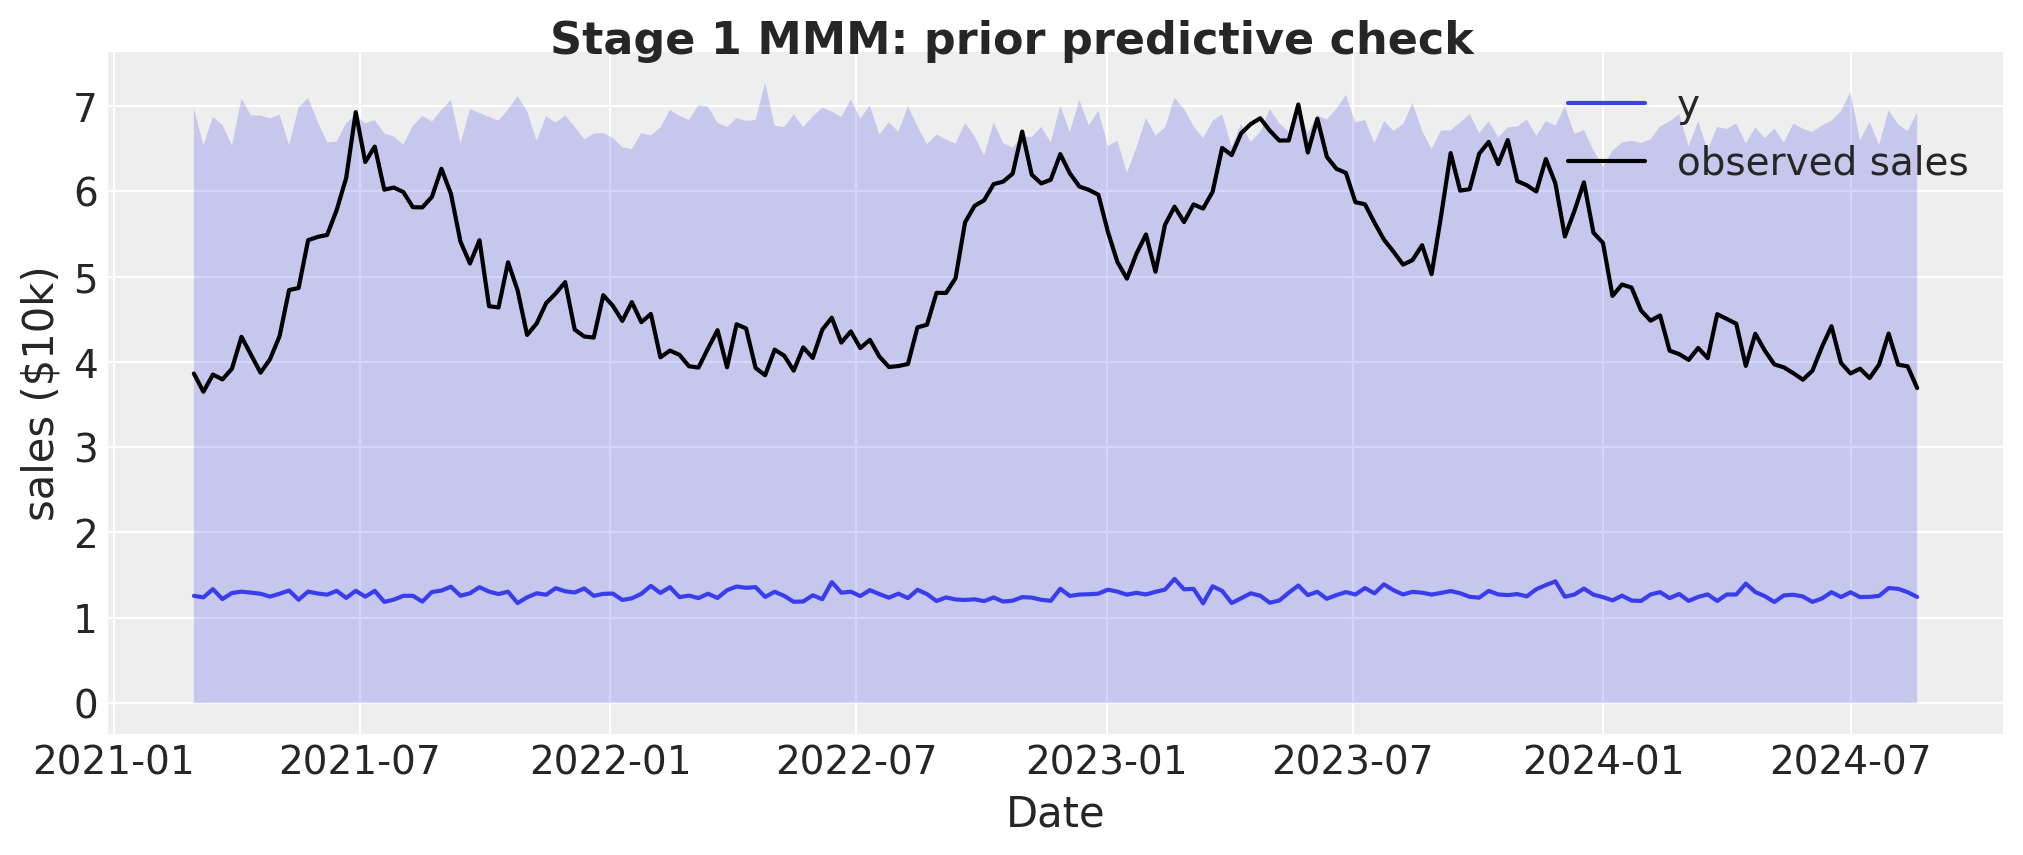

In [19]:
mmm.sample_prior_predictive(X, y, samples=2_000, random_seed=seed + 3)
fig, axes = mmm.plot.prior_predictive(hdi_prob=0.94)
ax = np.ravel(axes)[0]
ax.plot(df["date"], y, color="black", linewidth=1.5, label="observed sales")
ax.legend(loc="upper right")
ax.set(title="", ylabel="sales ($10k)")
fig.suptitle(
    "Stage 1 MMM: prior predictive check", fontsize=16, fontweight="bold", y=1.03
);

The 94% prior predictive band covers the observed sales path along the whole sample (the highest peaks graze its upper edge): the priors are on the right scale without being tuned to the data. We proceed to inference.

In [20]:
%%time
_ = mmm.fit(X, y, **(sampler_config | {"random_seed": seed + 2}))
_ = mmm.sample_posterior_predictive(
    X, extend_idata=True, combined=True, random_seed=seed + 4
)

NUTS[nutpie]: [intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, y_sigma]


Output()

Output()

Sampling: [y]


Output()

CPU times: user 2min 52s, sys: 2.06 s, total: 2min 54s
Wall time: 49.3 s


In [21]:
az.diagnose(mmm.idata)

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
The following parameters has R-hat values greater than 1.01:
  intercept_contribution_original_scale, yearly_seasonality_contribution, intercept_contribution, intercept_latent_process, intercept_latent_process_raw
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizing your model with additional prior information or a more effective parameterization.


True

In [22]:
az.summary(
    mmm.idata,
    var_names=[
        "saturation_beta",
        "adstock_alpha",
        "saturation_lam",
        "intercept_baseline",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
saturation_beta[x1],0.44,0.25,0.19,0.93,2130,2397,1.00,0.0055,0.0064
saturation_beta[x2],0.217,0.138,0.086,0.48,3612,3070,1.00,0.0025,0.0036
adstock_alpha[x1],0.507,0.071,0.39,0.62,4320,2741,1.00,0.0011,0.00077
adstock_alpha[x2],0.218,0.088,0.086,0.37,3991,3218,1.00,0.0014,0.00099
saturation_lam[x1],1.42,0.75,0.48,2.8,1923,2358,1.00,0.016,0.012
saturation_lam[x2],1.55,0.91,0.46,3.3,3509,3071,1.00,0.015,0.013
intercept_baseline,0.6357,0.0134,0.61,0.66,3020,3211,1.00,0.00025,0.00019


Since we simulated the data, we can compare the posteriors directly against the generating values. One subtlety: the model works on a max-scaled target, so the fitted `saturation_beta` lives in scaled units and the true value must be divided by `y.max()` before the comparison (`adstock_alpha` and `saturation_lam` act on the max-scaled spends, which are identical in the generator and the fitted model, so they compare directly).

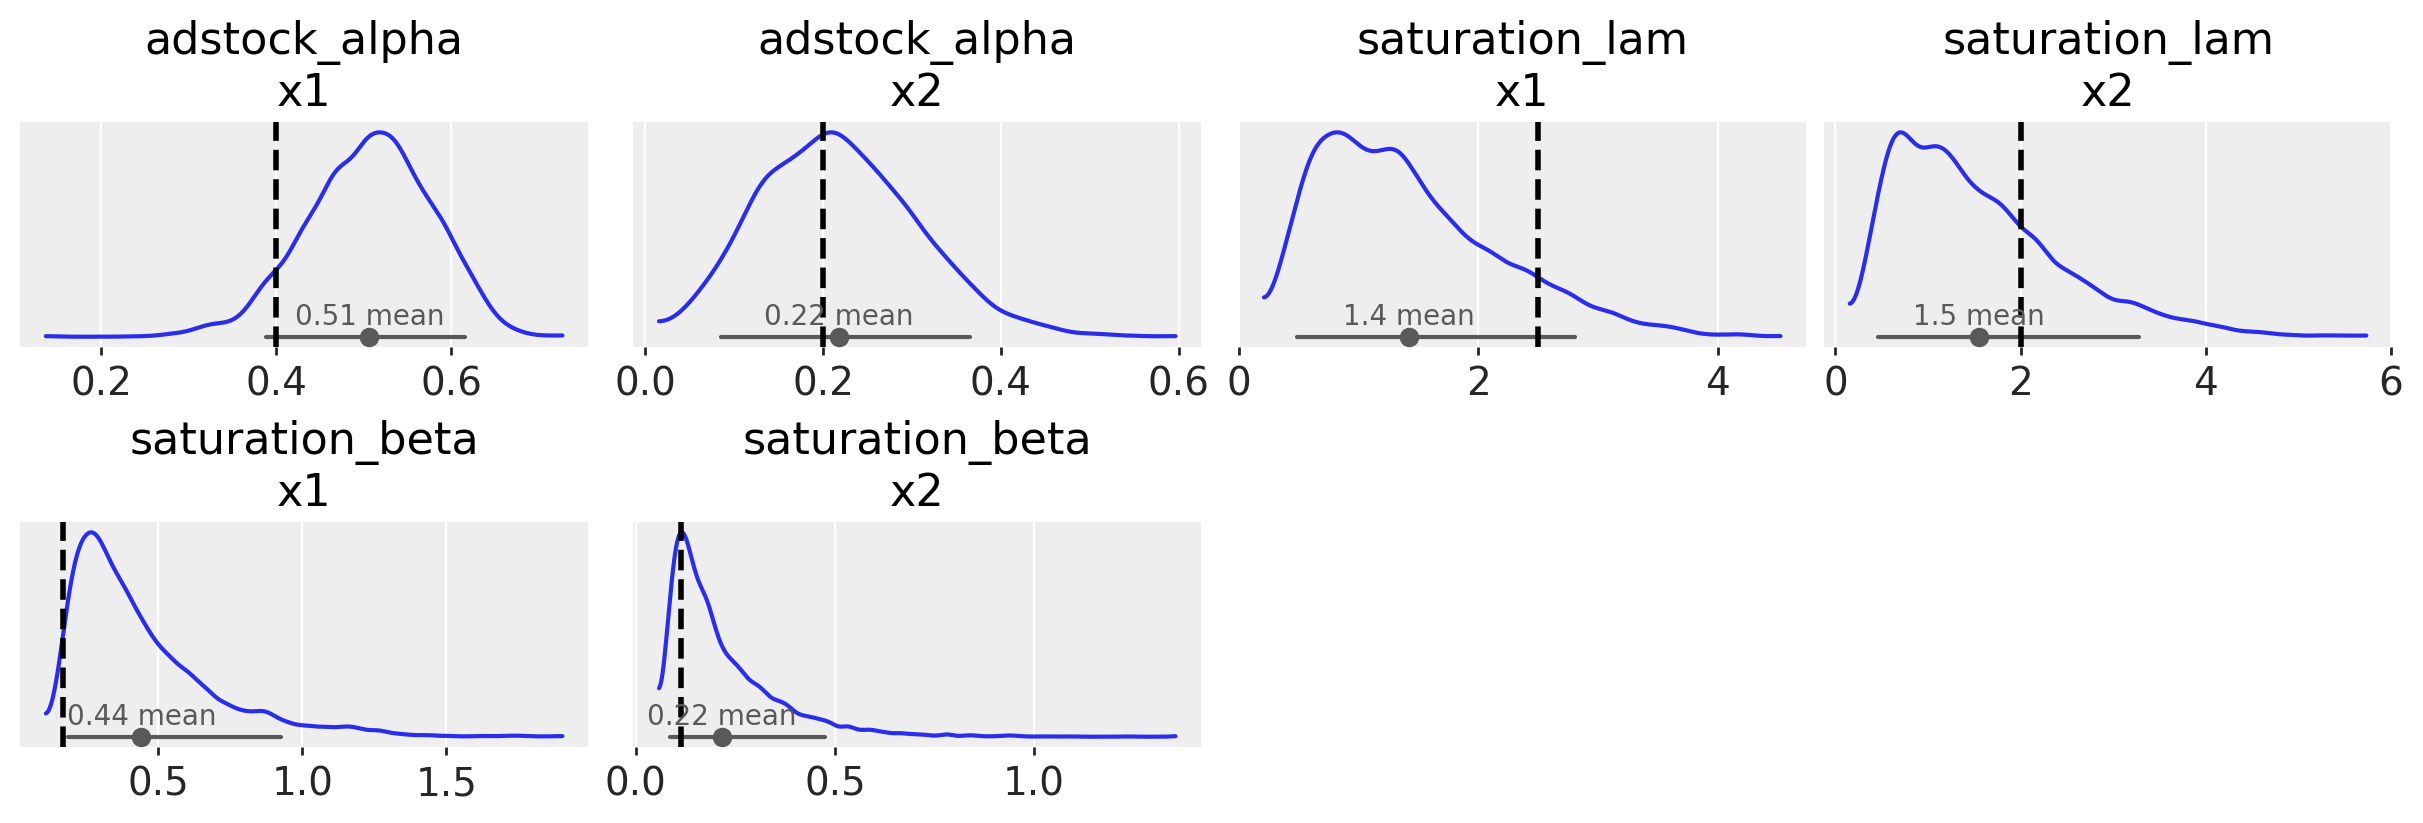

In [23]:
true_params = {
    "adstock_alpha": adstock_alpha_true,
    "saturation_lam": saturation_lam_true,
    "saturation_beta": saturation_beta_true / y.max(),
}

pc = az.plot_dist(
    mmm.idata,
    var_names=list(true_params),
    group="posterior",
    figure_kwargs={"figsize": (12, 4)},
)
for var, true_vals in true_params.items():
    for channel, true_val in zip(channels, true_vals, strict=True):
        ax = pc.viz["plot"][var].sel(channel=channel).item()
        ax.axvline(true_val, color="black", linestyle="--", linewidth=2)

Every true value (dashed line) falls inside its marginal posterior. The adstock parameters are pinned down tightly, while the saturation marginals are broader and not centered on the truth: `saturation_beta` and `saturation_lam` share the usual identification ridge (a higher ceiling with a slower curve produces nearly the same response over the observed spend range). What the data identify well is their *combination* — the realized response at observed spend levels — which is exactly what the ROI comparison below tests.

The decomposition below shows how the model splits sales between the performance channels and the evolving baseline.

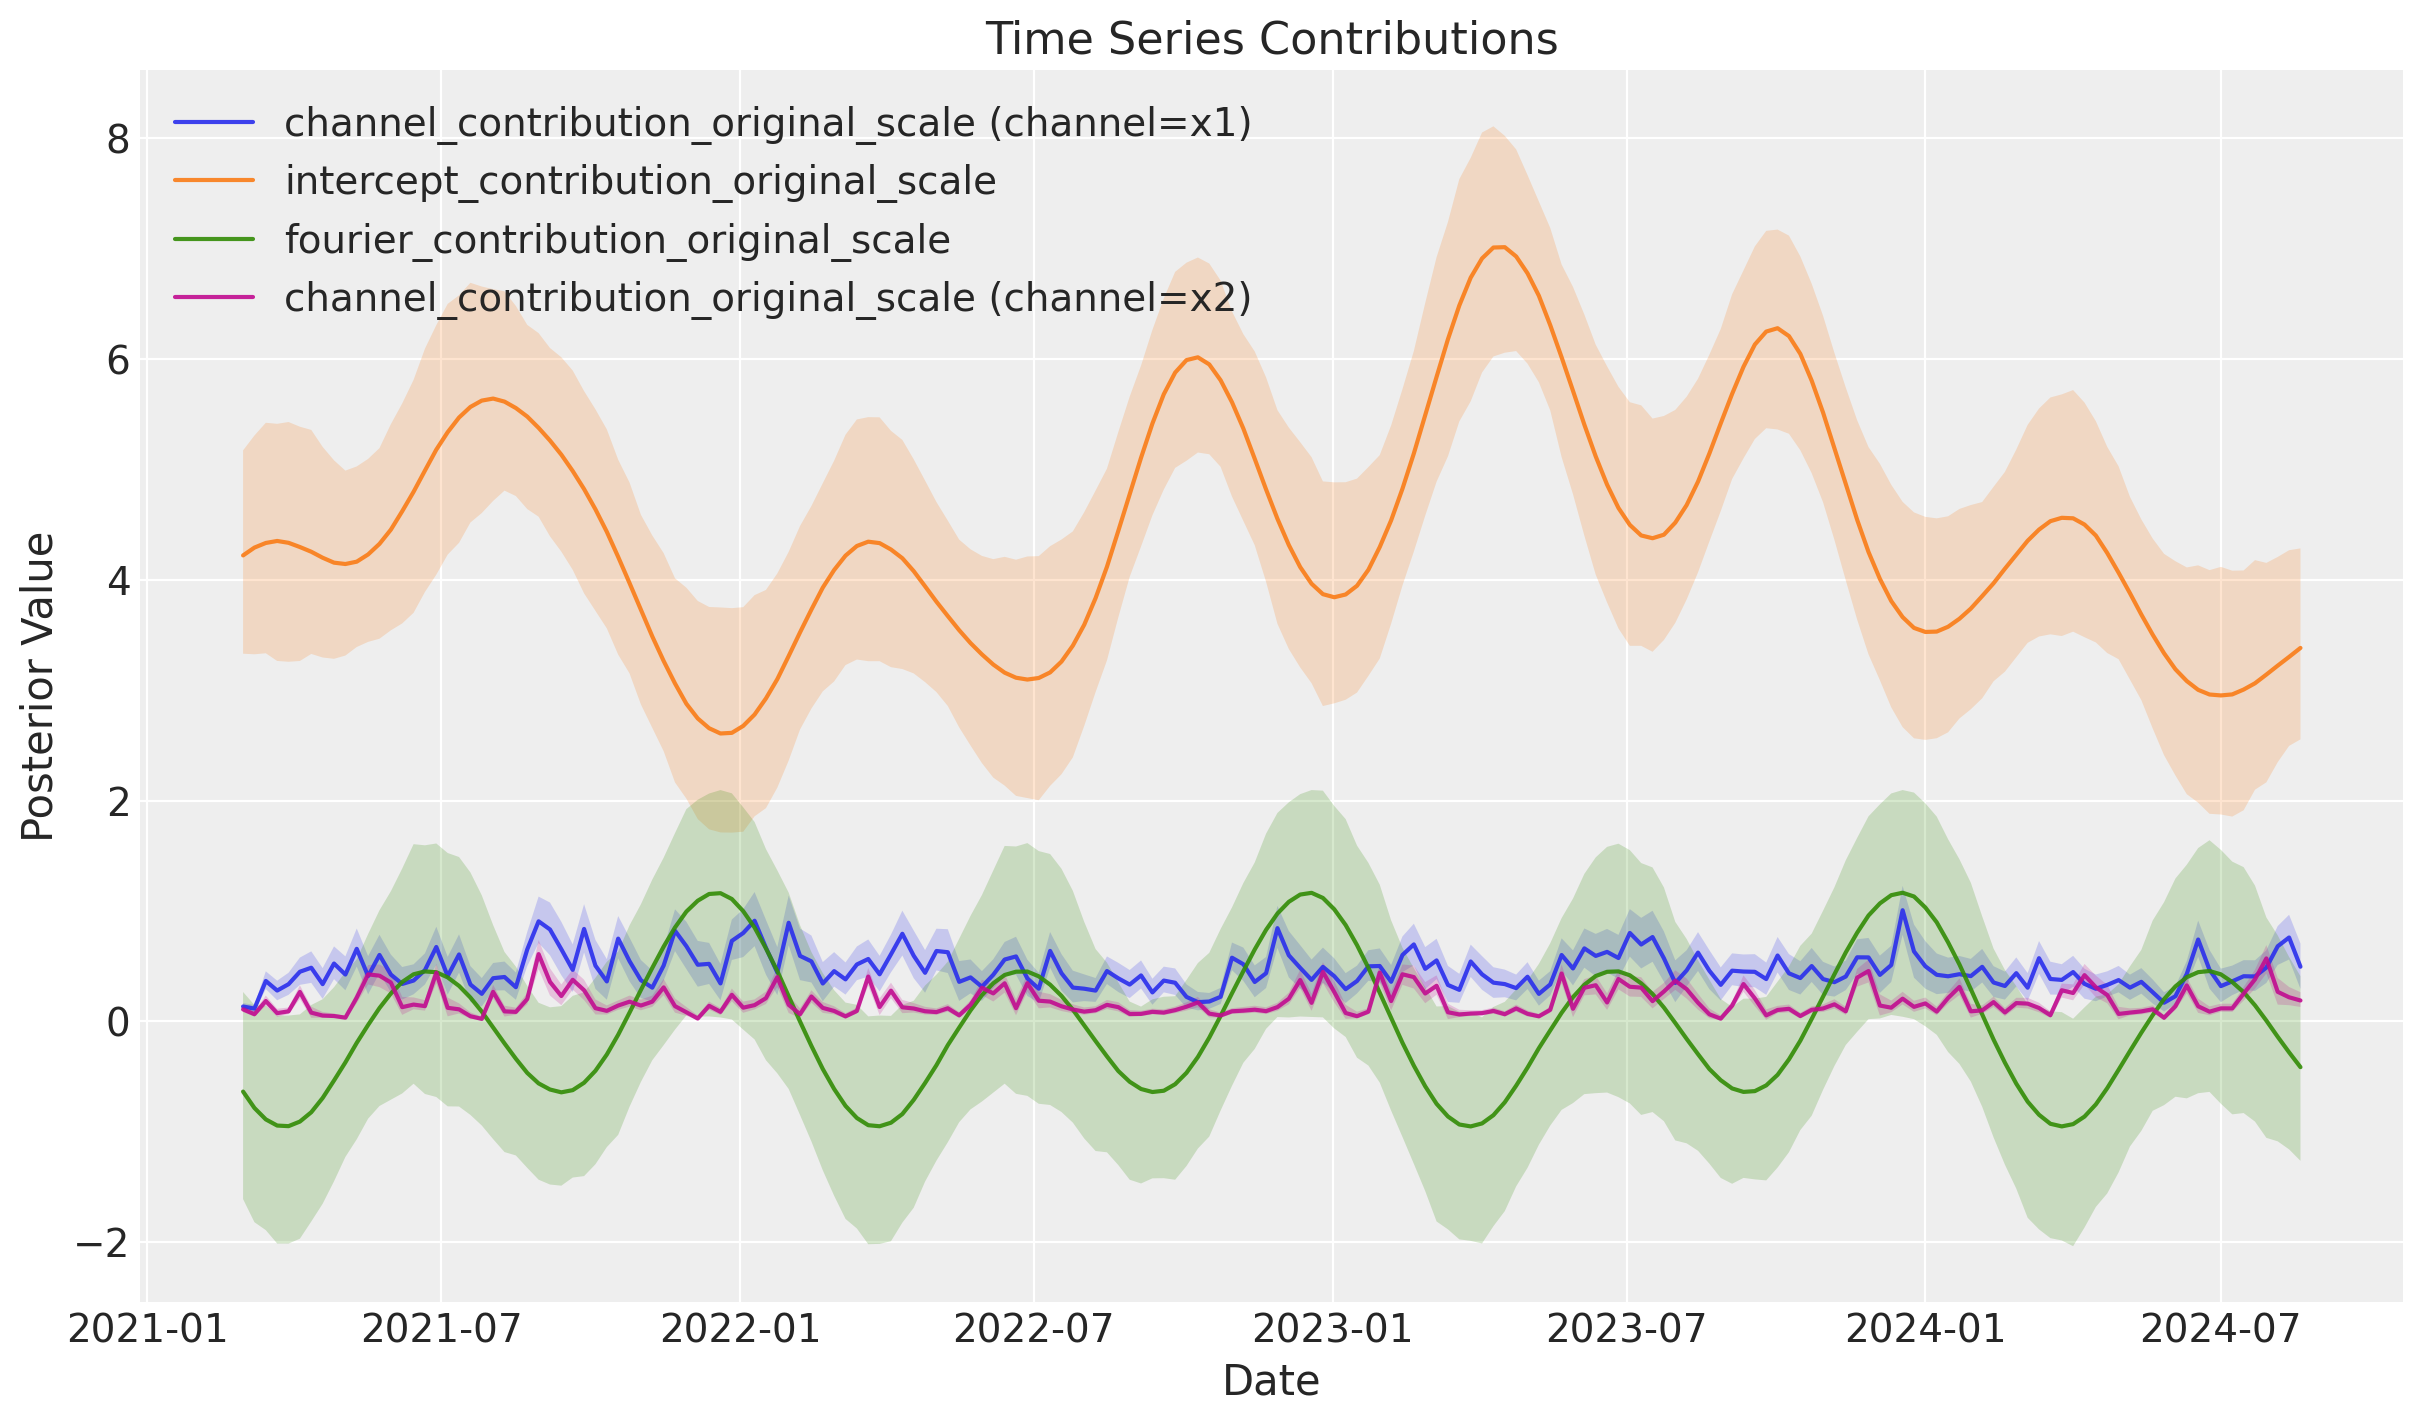

In [24]:
fig, axes = mmm.plot.contributions_over_time(
    var=[
        "channel_contribution_original_scale",
        "intercept_contribution_original_scale",
        "fourier_contribution_original_scale",
    ],
    dims={"channel": channels},
    combine_dims=True,
    hdi_prob=0.94,
    figsize=(12, 7),
)

The critical Stage-1 deliverable is the extracted baseline. Since we simulated the data, we can hold it against the true base sales path:

correlation(extracted baseline, true base sales) = 0.823


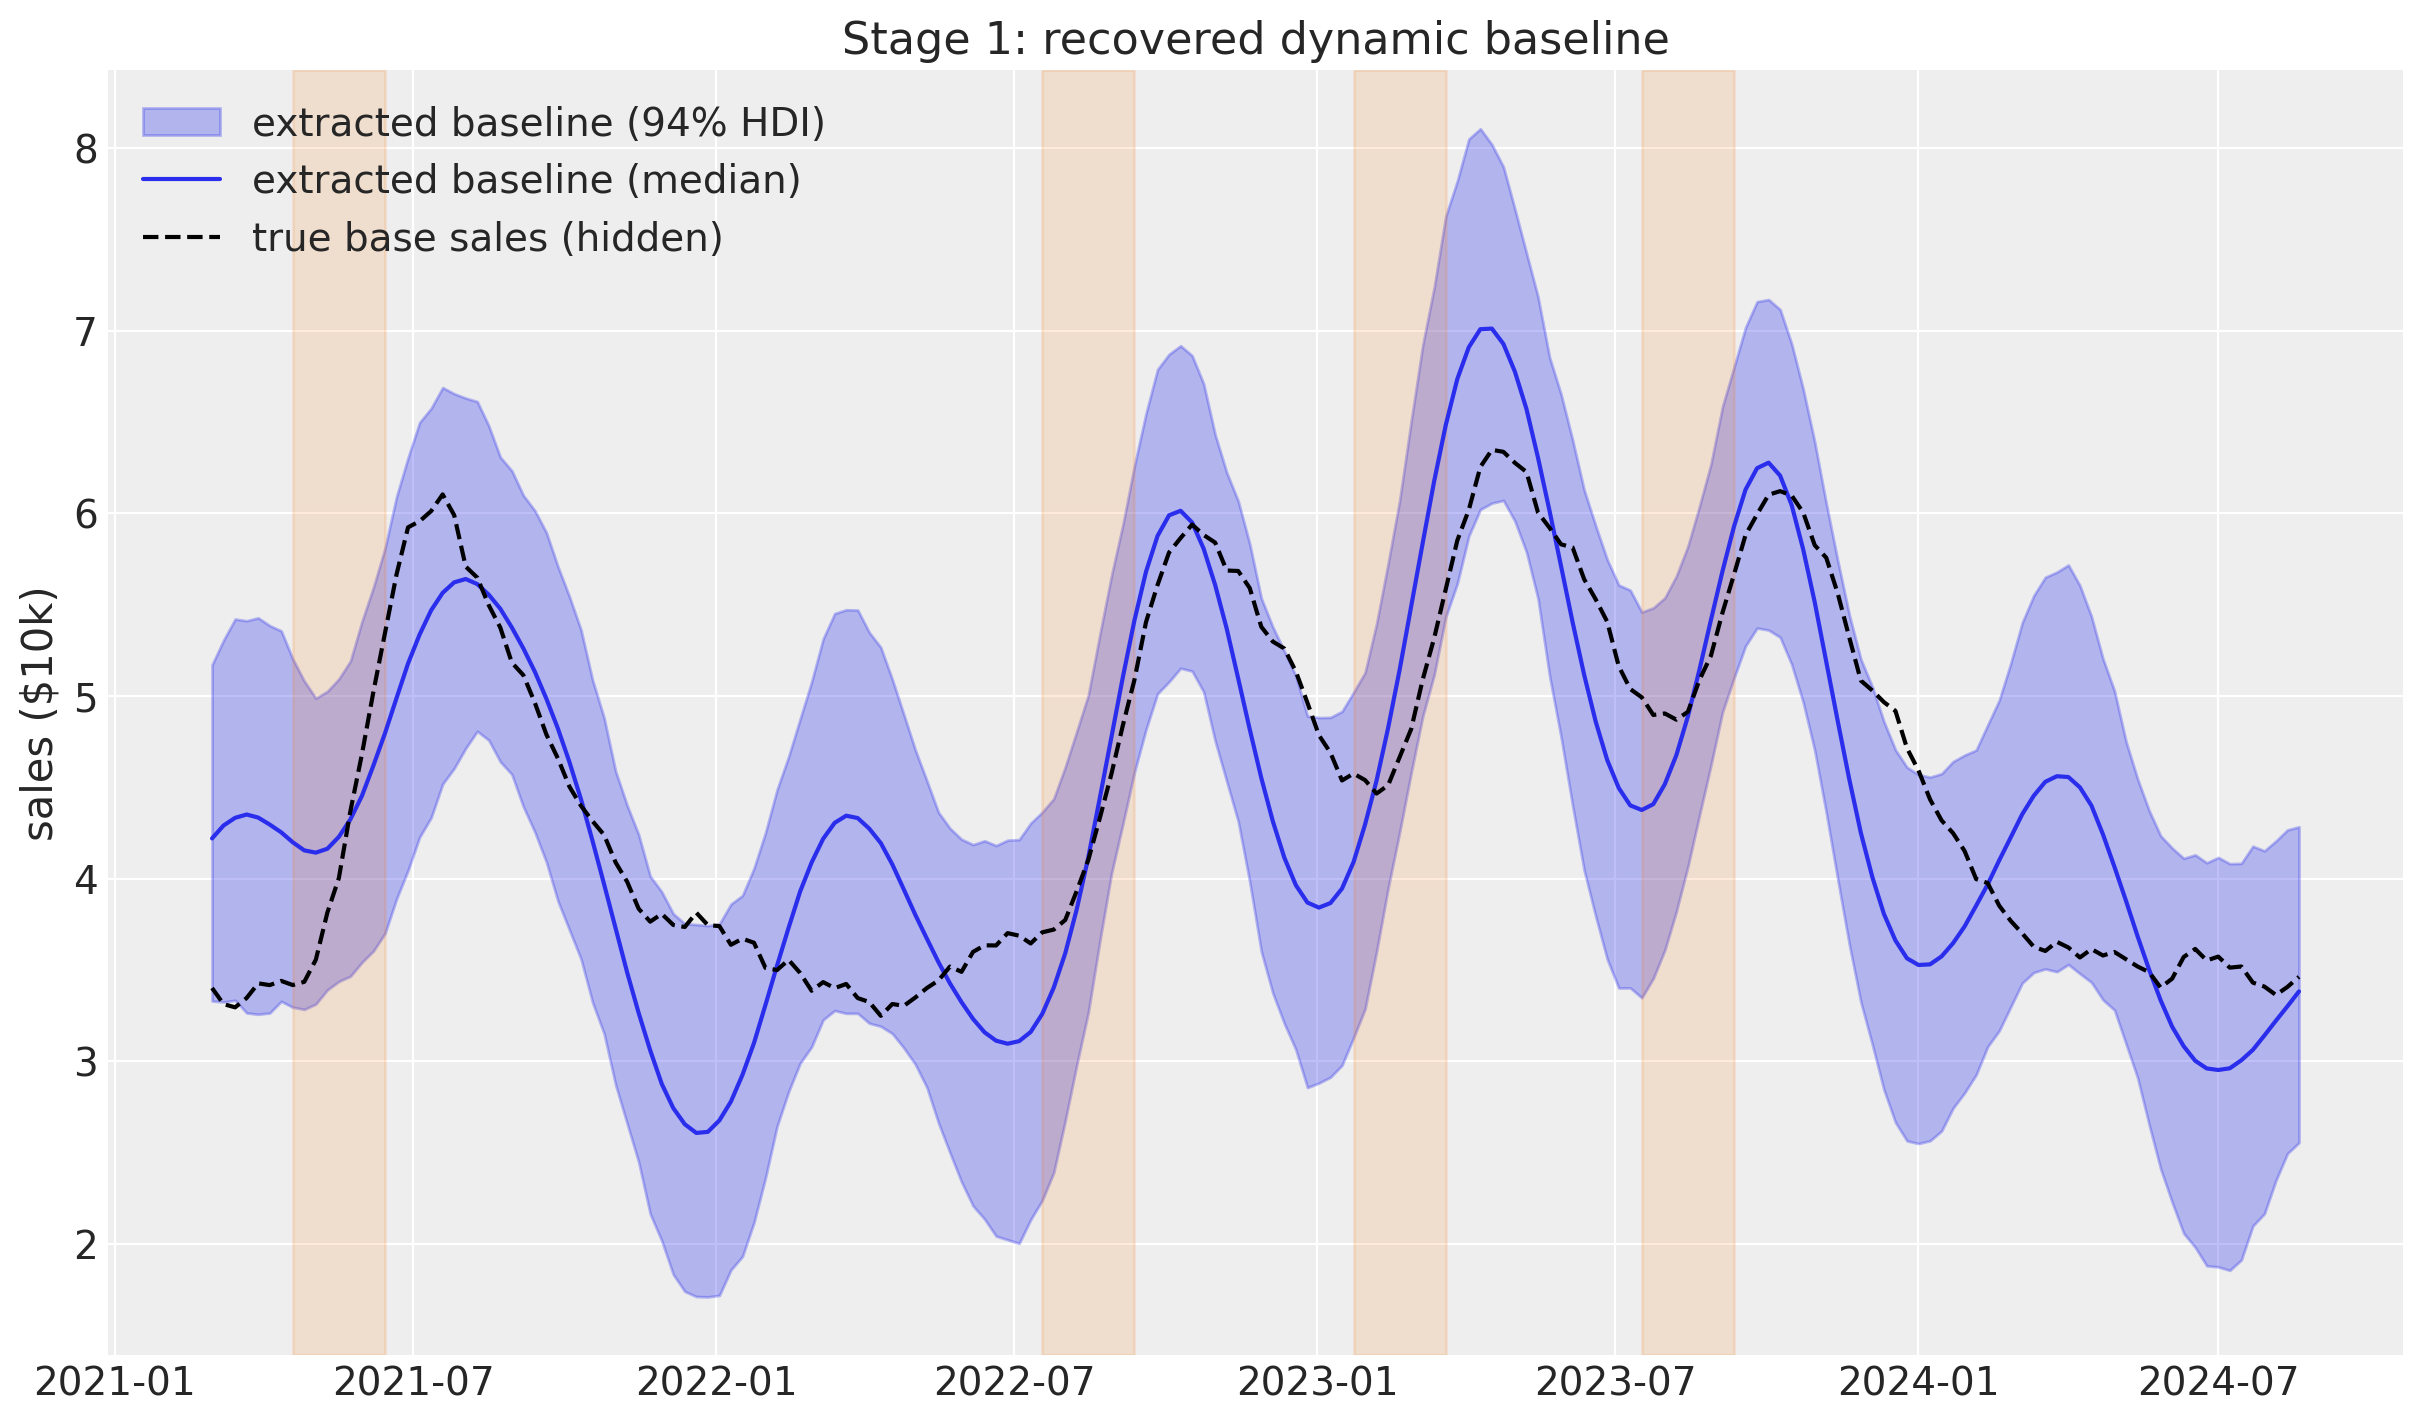

In [25]:
baseline_da = mmm.idata.posterior["intercept_contribution_original_scale"]
baseline_median = baseline_da.median(dim=("chain", "draw"))
baseline_hdi = az.hdi(baseline_da, prob=0.94)

fig, ax = plt.subplots()
ax.fill_between(
    df["date"],
    baseline_hdi.sel(ci_bound="lower"),
    baseline_hdi.sel(ci_bound="upper"),
    color="C0",
    alpha=0.3,
    label="extracted baseline (94% HDI)",
)
ax.plot(df["date"], baseline_median, color="C0", label="extracted baseline (median)")
ax.plot(
    truth_df["date"],
    truth_df["base_sales"],
    color="black",
    linestyle="--",
    label="true base sales (hidden)",
)
shade_flights(ax)
ax.legend(loc="upper left")
ax.set(title="Stage 1: recovered dynamic baseline", ylabel="sales ($10k)")

corr_baseline = np.corrcoef(baseline_median, truth_df["base_sales"])[0, 1]
print(f"correlation(extracted baseline, true base sales) = {corr_baseline:.3f}")

In [26]:
roi_stage1 = mmm.incrementality.contribution_over_spend(frequency="all_time").rename(
    "roi"
)
roi_stage1_hdi = az.hdi(roi_stage1, prob=0.94)

pd.DataFrame(
    {
        "recovered median": roi_stage1.median(dim=("chain", "draw")).to_series(),
        "hdi_low": roi_stage1_hdi.sel(ci_bound="lower").to_series(),
        "hdi_high": roi_stage1_hdi.sel(ci_bound="upper").to_series(),
        "true": [true_roi_x1, true_roi_x2],
    }
)

,recovered median,hdi_low,hdi_high,true
channel,,,,
x1,0.611006,0.422988,0.829281,0.529693
x2,0.359827,0.265311,0.476598,0.340416


The baseline tracks the true base sales closely (correlation of about 0.82; the wiggles are the price of a flexible GP, and some smoothing against the seasonal terms is expected), and the true short-term ROIs fall inside their recovered 94% intervals. Stage 1 has done its job: the brand-driven drift is now an explicit, extractable time series instead of a nuisance.

## Stage 2 Preparation: the VARX Frame and Stationarity

Stage 2 models the joint dynamics of the extracted baseline and the two survey metrics, with brand spend as an exogenous input. We assemble the frame (impulso's {class}`~impulso.VARData` requires a `DatetimeIndex`) using the posterior median of the baseline; we will return to the uncertainty we discard by doing so in the last section. To see the three endogenous series on one scale, we standardize them for display and shade the brand flights.

One measurement subtlety carries into this stage. The `awareness` and `consideration` columns are the *survey* series, which sit on top of the latent funnel states with observation noise (`survey_sigma = 0.03`, against a funnel innovation SD of `sigma_a = 0.04`, so the survey noise is roughly a third of the weekly innovation). Regressing on noisy proxies is a textbook errors-in-variables problem: it attenuates the estimated autoregressive and cross-lag coefficients and can therefore bias the long-run multiplier, typically downward. This sits alongside the Stage-1 baseline uncertainty we flag at the end as a second, structurally identical source of two-stage error. The oracle refit below lets us see how much the two together actually cost us here.

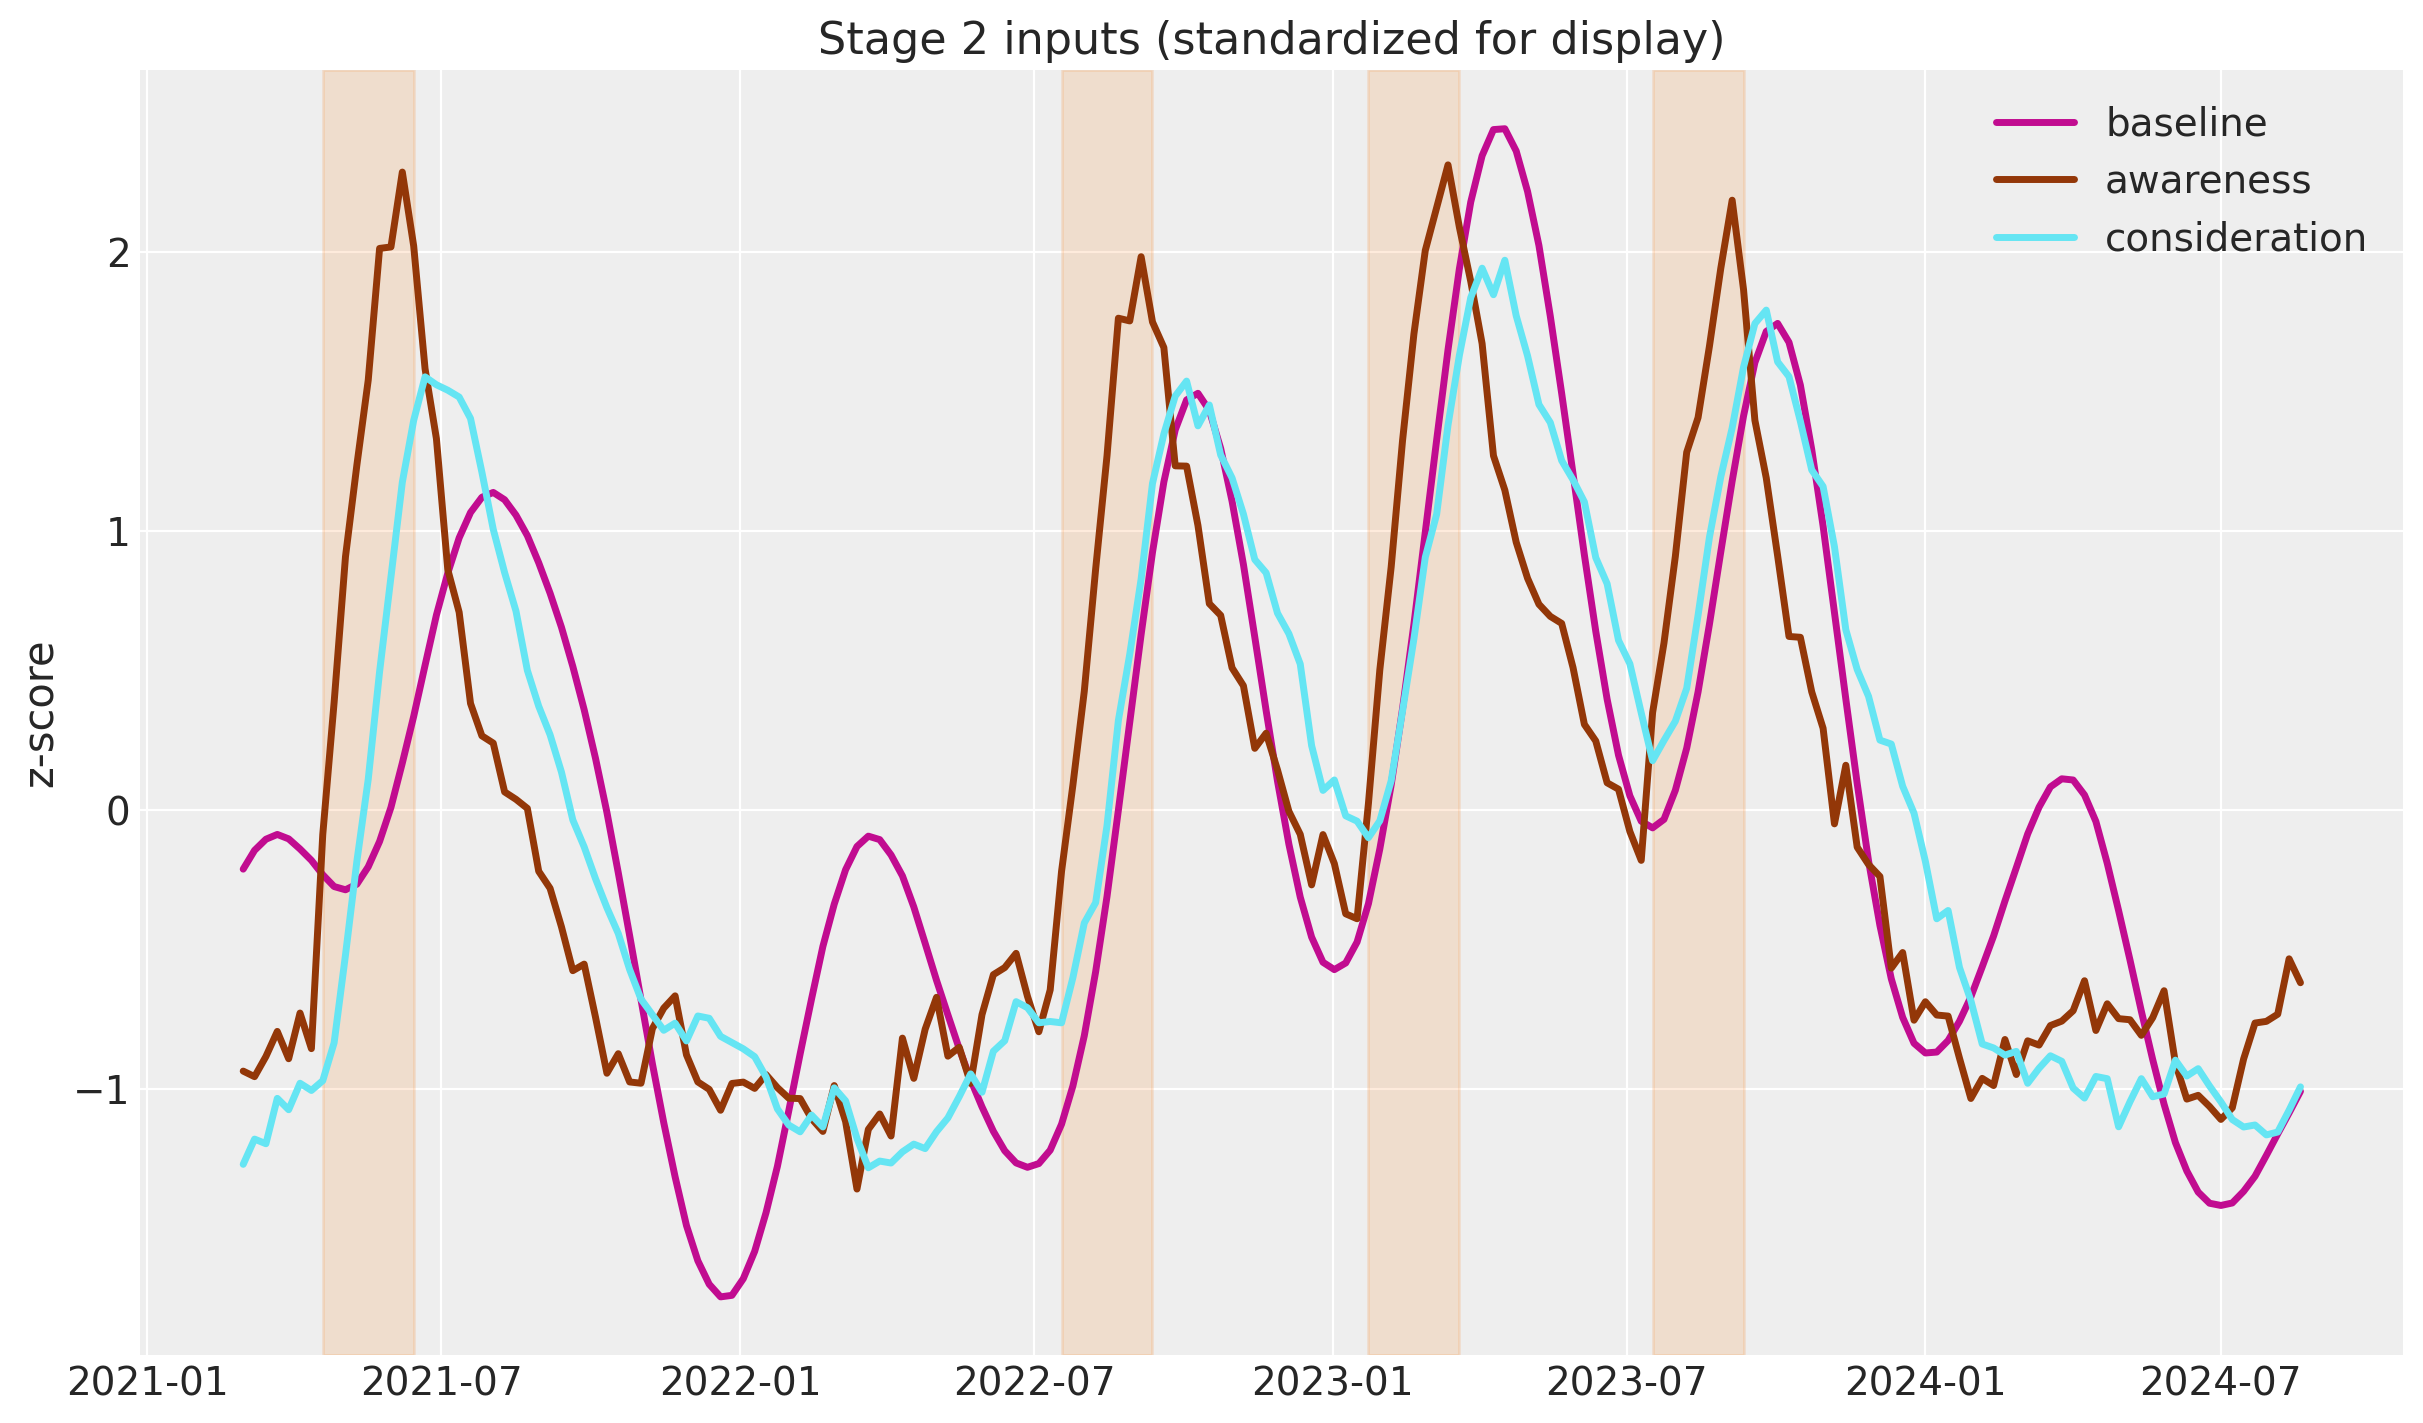

In [27]:
varx_df = pd.DataFrame(
    {
        "baseline": baseline_median.to_numpy(),
        "awareness": df["awareness"].to_numpy(),
        "consideration": df["consideration"].to_numpy(),
        "brand_spend": df["brand_spend"].to_numpy(),
    },
    index=pd.DatetimeIndex(df["date"], name="date"),
)

endog_vars = ["baseline", "awareness", "consideration"]

fig, ax = plt.subplots()
scaled = (varx_df[endog_vars] - varx_df[endog_vars].mean()) / varx_df[endog_vars].std()
for i, col in enumerate(endog_vars):
    ax.plot(varx_df.index, scaled[col], color=f"C{i + 3}", linewidth=2.5, label=col)

shade_flights(ax)
ax.legend(loc="upper right")
ax.set(
    title="Stage 2 inputs (standardized for display)",
    ylabel="z-score",
);

Awareness responds within each flight, consideration follows, and the baseline moves last: the funnel ordering is visible to the naked eye.

Before fitting a VAR we must ask a question that decides the entire Stage-2 specification: **are these series stationary?** A VAR in levels assumes the system fluctuates around a stable mean to which it eventually reverts. If instead the series are *integrated* (they contain a unit root, so shocks never die out), a levels regression among them can produce arbitrarily high $R^2$ and significant coefficients between series that are causally unrelated — the classic *spurious regression* problem — unless the series are cointegrated, in which case the right tool is a vector error correction model (VECM). Since the long-run multiplier we are after is built entirely from level relationships, getting this diagnosis wrong either invalidates the estimate (spurious levels VAR) or throws the estimand away (differencing). We therefore run three complementary tests.

**Augmented Dickey-Fuller (ADF).** The null hypothesis is that the series has a *unit root* (non-stationary); the alternative is stationarity. It regresses the differenced series on its lagged level and lagged differences and asks whether the lagged-level coefficient is negative enough to imply mean reversion. Read the table by comparing the test statistic against the critical value (or the p-value against 0.05): a statistic *more negative* than the critical value rejects the unit root, i.e. declares the series stationary. Its weakness matters here: against *persistent-but-stationary* alternatives (autoregressive roots near one, exactly what a brand funnel produces) the test has notoriously low power in short samples, so a failure to reject is weak evidence of a unit root.

In [28]:
adf_test(varx_df, variables=endog_vars).table

,statistic,pvalue,lags,crit_1pct,crit_5pct,crit_10pct,reject,conclusion
variable,,,,,,,,
baseline,-1.367407,0.597798,13,-3.469886,-2.878903,-2.576027,False,non-stationary
awareness,-2.145728,0.226529,8,-3.468726,-2.878396,-2.575756,False,non-stationary
consideration,-2.514371,0.112017,6,-3.468280,-2.878202,-2.575653,False,non-stationary


**KPSS.** The burden of proof is reversed: the null hypothesis is *stationarity* and the alternative is a unit root, so here a *large* test statistic (above the critical value) is evidence of non-stationarity. Running KPSS alongside ADF gives a two-by-two verdict grid: ADF rejects and KPSS does not — confidently stationary; ADF fails to reject and KPSS rejects — confidently integrated; both reject, or neither does — the sample is too short or the series too persistent for a clean verdict, which is the most common outcome with three or four years of weekly marketing data.

In [29]:
kpss_test(varx_df, variables=endog_vars).table

,statistic,pvalue,lags,crit_1pct,crit_2_5pct,crit_5pct,crit_10pct,pvalue_bounded,reject,conclusion
variable,,,,,,,,,,
baseline,0.165053,0.1,9,0.739,0.574,0.463,0.347,True,False,stationary
awareness,0.175315,0.1,9,0.739,0.574,0.463,0.347,True,False,stationary
consideration,0.205504,0.1,9,0.739,0.574,0.463,0.347,True,False,stationary


**Johansen cointegration test.** While ADF and KPSS interrogate each series on its own, the Johansen trace test looks at the *system*: it estimates the cointegration rank $r$, the number of independent stationary linear combinations of the three series. The table reports a sequence of nested hypotheses ($r \le 0$, $r \le 1$, $r \le 2$); read it top-down and stop at the first hypothesis you cannot reject. Rank 0 with integrated series means no stable level relationships (a levels VAR would be spurious); an intermediate rank means cointegration (fit a VECM); rejecting at *every* rank means the system is full-rank stationary, and a **VAR in levels** is directly valid.

In [30]:
johansen_test(varx_df[endog_vars]).table

,trace_stat,trace_crit,trace_reject,maxeig_stat,maxeig_crit,maxeig_reject
r,,,,,,
0,380.227369,29.7961,True,227.832131,21.1314,True
1,152.395238,15.4943,True,139.370216,14.2639,True
2,13.025022,3.8415,True,13.025022,3.8415,True


The verdicts are mixed, and that is realistic: every series in our simulation is stationary by construction (all autoregressive roots are below one), yet the ADF test fails to reject a unit root for *all three* series, while KPSS fails to reject stationarity for all three — jointly, the ambiguous cell of the two-by-two grid described above. Persistent-but-stationary series in a three-and-a-half-year sample routinely fool unit-root tests, and the ADF regression is in any case misspecified for series driven by an exogenous input like the flight schedule. The Johansen test resolves the ambiguity here: it rejects at every rank, which means the system is best treated as full-rank stationary, so a **VAR in levels** is directly appropriate.

With real data, expect this ambiguity to be the rule. If the tests do point to integrated series linked by a cointegrating relationship, the textbook answer is a vector error correction model (VECM), which is exactly the road Cain (2022) takes; impulso does not currently ship a VECM, and a levels VAR with a Minnesota prior (which shrinks toward random-walk behavior) is a common pragmatic substitute under high persistence. What you should *not* do is difference the series, since differencing destroys the level relationships that the long-run multiplier is made of.

## Stage 2: Bayesian VARX with impulso

The model for the endogenous vector $z_t = (\text{baseline}_t, \text{awareness}_t, \text{consideration}_t)^\top$ is a one-lag VARX,

$$
z_t = a + A \, z_{t-1} + B_{\text{exog}} \, \text{brand}_t + \varepsilon_t,
\qquad \varepsilon_t \sim \text{MultivariateNormal}(0, \Sigma),
$$

with a Minnesota prior on the lag coefficients. Three features of this setup deserve emphasis:

- **No structural identification is needed.** For questions about shocks to *endogenous* variables a VAR needs identifying restrictions (Cholesky ordering, sign restrictions). Our question is about the *exogenous* input: brand spend is set by the planner's flight calendar, so the reduced-form coefficient $B_{\text{exog}}$ already has a causal interpretation, exactly as in {ref}`mmm_var_budget_optimization`.
- **Timing convention.** Brand spend enters contemporaneously, matching the data generating process where a flight lifts awareness within the same week.
- **Lag order: stay parsimonious.** Weekly funnel dynamics are well captured by a single lag, and every extra lag adds nine coefficients that must be pinned down by, effectively, four campaign flights. There is a subtler danger too: the baseline series carries Stage-1 estimation error, and information criteria respond to that noise by demanding *more* lags — on this data (the check below) AIC asks for seven and BIC and HQ for four, well above the single lag the weekly dynamics actually need — which then dilute the brand transmission across a long lag polynomial and bias the long-run multiplier downward. Use information criteria as a starting point with real data, but prefer the smallest lag order compatible with the dynamics you believe in, and check robustness to the choice.

We keep the default nearly-flat prior scale on $B_{\text{exog}}$: shrinking the exogenous coefficients toward zero would bias the very effect we are trying to measure.

In [31]:
%%time
var_data = VARData.from_df(varx_df, endog=endog_vars, exog=["brand_spend"])

varx = VAR(lags=1, prior="minnesota")
fitted = varx.fit(
    var_data,
    sampler=NUTSSampler(
        nuts_sampler="nutpie",
        draws=1_000,
        tune=1_000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed=seed + 1,
    ),
)

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

CPU times: user 16.8 s, sys: 541 ms, total: 17.3 s
Wall time: 8.48 s


In [32]:
# Lag-order selection is a fast OLS computation via impulso's public helper, so
# we can show what the information criteria ask for without a second MCMC fit.
lag_selection = select_lag_order(var_data, max_lags=8)
print("AIC-selected lag order:", lag_selection.aic)
print("BIC-selected lag order:", lag_selection.bic)
print("HQ-selected lag order: ", lag_selection.hq)
lag_selection.criteria_table

AIC-selected lag order: 7
BIC-selected lag order: 4
HQ-selected lag order:  4


,aic,bic,hq
lag,,,
1,-15.853394,-15.588325,-15.745929
2,-19.743181,-19.317454,-19.570567
3,-20.806391,-20.218772,-20.568116
4,-20.982473,-20.231715,-20.678021
5,-20.915435,-20.000273,-20.544281
6,-20.892327,-19.811481,-20.453941
7,-20.984603,-19.736773,-20.478448
8,-20.932006,-19.515877,-20.357537


In [33]:
az.diagnose(fitted.idata)

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


False

In [34]:
az.summary(fitted.idata, var_names=["B_exog"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"B_exog[baseline, brand_spend]",0.1322,0.0319,0.083,0.18,4287,3247,1.00,0.00049,0.00035
"B_exog[awareness, brand_spend]",0.2554,0.0146,0.23,0.28,3332,3131,1.00,0.00025,0.00018
"B_exog[consideration, brand_spend]",0.0348,0.0138,0.013,0.057,3619,3410,1.00,0.00023,0.00016


The posterior on $B_{\text{exog}}$ already shows the funnel at work: brand spend moves awareness contemporaneously ($\approx 0.26$ against a true $\gamma = 0.25$) and barely touches consideration within the week ($\approx 0.03$). It also picks up a small positive same-week loading on the baseline ($\approx 0.13$), even though the true contemporaneous effect on base sales is zero: the GP-smoothed Stage-1 baseline spreads each flight's effect slightly across neighboring weeks, and the VARX reads part of that as a within-week response. Keep this artifact in mind when we inspect the short-horizon multiplier below. The long-term story lives in the *dynamic multiplier*, which is worth unpacking step by step.

A stationary VAR can be rewritten in its moving-average form: today's state is a weighted sum of all past inputs, $z_t = \sum_{h \ge 0} \Phi_h \left( B_{\text{exog}} \, \text{brand}_{t-h} + \varepsilon_{t-h} \right) + \dots$, where the MA matrices follow the recursion $\Phi_0 = I$ and $\Phi_h = \sum_{j=1}^{p} A_j \Phi_{h-j}$ built from the estimated lag matrices $A_j$. The **dynamic multiplier** at horizon $h$ is

$$
\Psi_h = \Phi_h B_{\text{exog}}, \qquad h = 0, 1, 2, \dots
$$

and it answers a precise counterfactual: *if we add one unit of brand spend this week and change nothing else, how much higher are the baseline, awareness, and consideration $h$ weeks from now?* At $h=0$ it is just $B_{\text{exog}}$ (the same-week effect); at larger $h$ the impulse travels through the estimated lag structure — spend lifts awareness, lagged awareness feeds consideration, lagged consideration feeds the baseline — and gradually decays as the stationary system reverts to its mean. The cumulative sum $\sum_{j=0}^{h} \Psi_j$ is the **total** incremental effect realized within $h$ weeks per unit of spend, which at $h = 26$ becomes our long-term brand ROI. Because brand spend is exogenous, no structural identification is needed for this to carry a causal reading.

We evaluate this for every posterior draw with impulso's public `compute_ma_phi` and `lag_matrices` helpers (the same route as {ref}`mmm_var_budget_optimization`), so the multiplier inherits full posterior uncertainty from $A$ and $B_{\text{exog}}$. The small `posterior_dynamic_multiplier` helper below wraps them and labels the result.

```{note}
We compute the multiplier manually rather than through {meth}`~impulso.fitted.FittedVAR.dynamic_multiplier`. impulso 0.0.10 builds its return object with `az.InferenceData(...)`, but ArviZ 1.x replaces `InferenceData` with `xarray.DataTree`, whose constructor rejects those keyword groups, so the convenience method raises under this environment. For the same reason, calling `.plot()` or `.median()` on a `DynamicMultiplierResult` also fails (both route through the 1.x `az.hdi`, whose argument is `prob=` and whose dimension is `ci_bound`). The `compute_ma_phi` path sidesteps all of this.
```

We keep the per-horizon draws (`theta_plugin`) for the in-sample decomposition later and accumulate them over the horizon for the ROI story.

In [35]:
def posterior_dynamic_multiplier(fitted_var, horizon: int) -> xr.DataArray:
    """Per-draw dynamic multiplier ``Psi_h = Phi_h @ B_exog`` for ``h = 0..horizon``.

    Built directly from impulso's public ``compute_ma_phi`` / ``lag_matrices``
    exports rather than ``FittedVAR.dynamic_multiplier``, so it does not touch
    the ArviZ 1.x ``InferenceData`` constructor discussed above. ``compute_ma_phi``
    returns ``Phi_0 ... Phi_horizon`` inclusive, so we pass ``horizon`` directly.
    """
    posterior = fitted_var.idata.posterior
    B_draws = posterior["B"].transpose("chain", "draw", "var", "coeff").values
    B_exog_draws = posterior["B_exog"].transpose("chain", "draw", "var", "exog").values
    phi = compute_ma_phi(
        lag_matrices(B_draws, n_lags=fitted_var.n_lags), horizon=horizon
    )
    theta = phi @ B_exog_draws[:, :, np.newaxis, :, :]
    return xr.DataArray(
        theta,
        dims=("chain", "draw", "horizon", "response", "exog"),
        coords={
            "horizon": np.arange(horizon + 1),
            "response": list(fitted_var.var_names),
            "exog": list(fitted_var.data.exog_names),
        },
        name="dynamic_multiplier",
    )


# Plug-in multiplier: conditioned on the single median-baseline VARX fit.
theta_plugin = posterior_dynamic_multiplier(fitted, horizon=horizon)
cum_multiplier_plugin = theta_plugin.cumsum("horizon")

expected_plugin_sizes = {
    "chain": 4,
    "draw": 1_000,
    "horizon": horizon + 1,
    "response": 3,
    "exog": 1,
}
if dict(theta_plugin.sizes) != expected_plugin_sizes:
    raise ValueError(f"unexpected plug-in multiplier shape: {dict(theta_plugin.sizes)}")

### Where does the same-week baseline loading come from?

The plug-in $B_{\text{exog}}$ showed a small positive contemporaneous loading on the baseline, which the true funnel does not have. Two mechanisms could produce it: Stage-1 error (the GP-smoothed baseline smears each flight across neighboring weeks) or Stage-2 misspecification. Because the data are simulated we can settle it with an *oracle* refit of the identical VARX on the true latent series. We do it in two steps so the attribution is clean: first swap in only the true baseline while keeping the noisy surveys (this isolates the Stage-1 baseline-extraction error), then swap in the latent surveys as well (this isolates Stage-2 recovery under a perfect Stage 1). Each fit costs a few seconds.

In [36]:
%%time
oracle_index = pd.DatetimeIndex(df["date"], name="date")


def fit_oracle_varx(frame: pd.DataFrame, random_seed: int):
    return VAR(lags=1, prior="minnesota").fit(
        VARData.from_df(frame, endog=endog_vars, exog=["brand_spend"]),
        sampler=NUTSSampler(
            nuts_sampler="nutpie",
            draws=1_000,
            tune=1_000,
            chains=4,
            cores=4,
            target_accept=0.95,
            random_seed=random_seed,
        ),
    )


# True baseline, still-noisy surveys: isolates Stage-1 baseline-extraction error.
oracle_baseline_df = pd.DataFrame(
    {
        "baseline": truth_df["base_sales"].to_numpy(),
        "awareness": df["awareness"].to_numpy(),
        "consideration": df["consideration"].to_numpy(),
        "brand_spend": df["brand_spend"].to_numpy(),
    },
    index=oracle_index,
)
# True baseline and latent surveys: isolates Stage-2 recovery under a perfect Stage 1.
oracle_full_df = pd.DataFrame(
    {
        "baseline": truth_df["base_sales"].to_numpy(),
        "awareness": truth_df["awareness_latent"].to_numpy(),
        "consideration": truth_df["consideration_latent"].to_numpy(),
        "brand_spend": df["brand_spend"].to_numpy(),
    },
    index=oracle_index,
)

fitted_oracle_baseline = fit_oracle_varx(oracle_baseline_df, seed + 7)
fitted_oracle_full = fit_oracle_varx(oracle_full_df, seed + 8)


def _oracle_row(fitted_var) -> dict[str, float]:
    b_exog_baseline = fitted_var.idata.posterior["B_exog"].sel(
        var="baseline", exog="brand_spend"
    )
    cum_baseline = (
        posterior_dynamic_multiplier(fitted_var, horizon=horizon)
        .cumsum("horizon")
        .sel(response="baseline", exog="brand_spend", horizon=horizon)
    )
    return {
        "B_exog[baseline] median": float(b_exog_baseline.median()),
        "26-week multiplier median": float(cum_baseline.median()),
    }


oracle_comparison = pd.DataFrame(
    {
        "plug-in (median baseline)": _oracle_row(fitted),
        "oracle: true baseline": _oracle_row(fitted_oracle_baseline),
        "oracle: true baseline + surveys": _oracle_row(fitted_oracle_full),
    }
).T
oracle_comparison["true multiplier"] = true_long_term_roi
oracle_comparison

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

CPU times: user 56.9 s, sys: 1.21 s, total: 58.1 s
Wall time: 22.5 s


,B_exog[baseline] median,26-week multiplier median,true multiplier
plug-in (median baseline),0.132190,5.563279,5.151932
oracle: true baseline,-0.023272,4.755593,5.151932
oracle: true baseline + surveys,-0.024928,4.733243,5.151932


The comparison localizes each source of error. Swapping in the true baseline (row two) collapses the same-week `B_exog[baseline]` loading from about $+0.13$ to roughly $-0.02$, confirming that the plug-in's positive contemporaneous term was Stage-1 GP leakage rather than a Stage-2 artifact. Adding the latent surveys on top (row three) barely moves the multiplier ($4.76 \to 4.73$), so survey measurement error costs little here; the errors-in-variables attenuation we flagged is real but small on this data. Both oracle multipliers land a little *below* the true $5.15$ (near $4.7$–$4.8$), which is the honest residual: a one-lag VAR is a compact approximation to the true multi-equation funnel, and that structural gap, not measurement noise, dominates once the inputs are clean. The plug-in's own median ($\approx 5.56$) sits close to the truth largely because its upward GP-leakage bias happens to offset this downward structural bias — a coincidence, not a reason to trust the plug-in over the honest, uncertainty-propagated headline below.

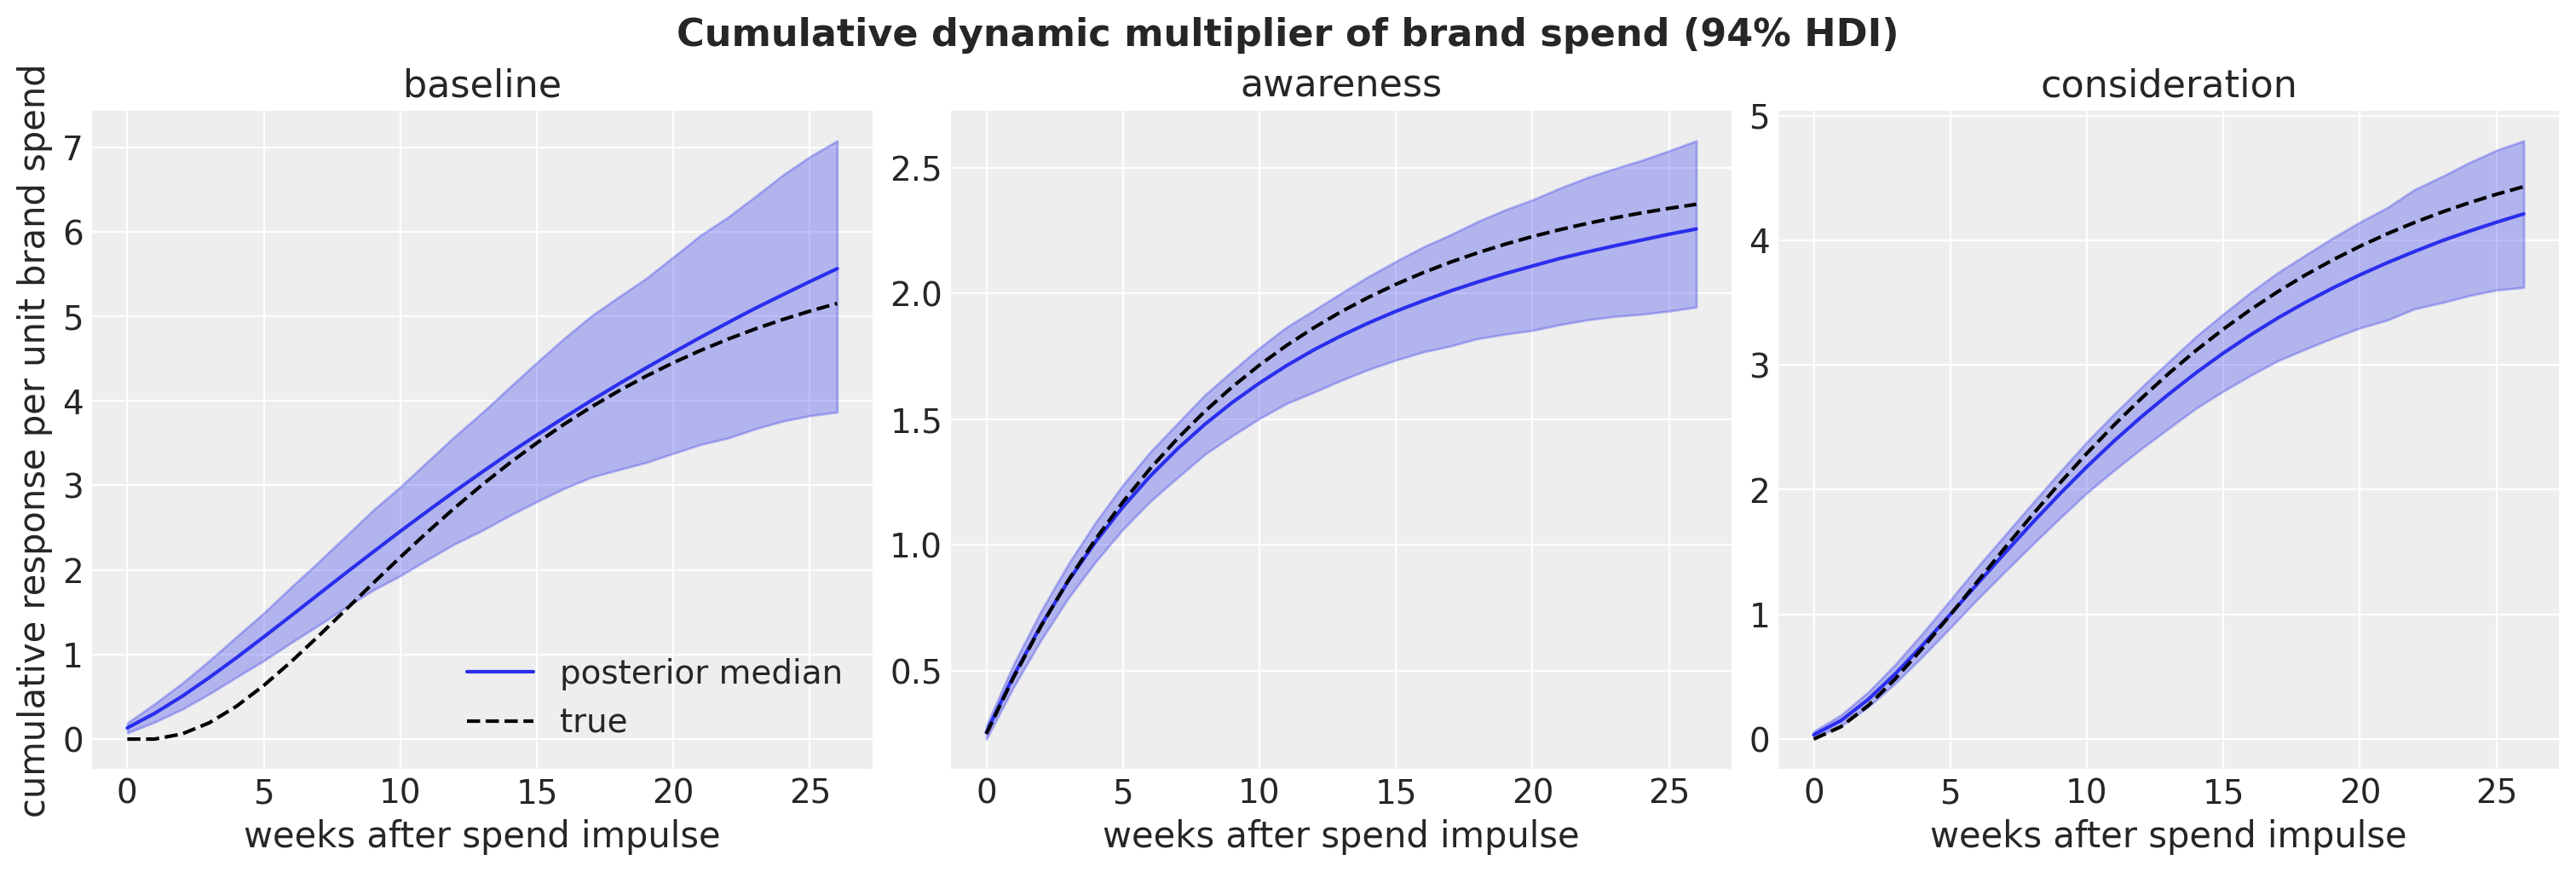

In [37]:
true_curves = {
    "baseline": np.cumsum(impulse_b),
    "awareness": np.cumsum(impulse_a),
    "consideration": np.cumsum(impulse_c),
}

fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 5), sharex=True, layout="constrained"
)
for ax, response in zip(axes, ["baseline", "awareness", "consideration"], strict=True):
    curve = cum_multiplier_plugin.sel(response=response, exog="brand_spend")
    median = curve.median(dim=("chain", "draw"))
    hdi = az.hdi(curve, prob=0.94)
    ax.fill_between(
        curve["horizon"],
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        alpha=0.3,
        color="C0",
    )
    ax.plot(curve["horizon"], median, color="C0", label="posterior median")
    ax.plot(
        curve["horizon"],
        true_curves[response],
        color="black",
        linestyle="--",
        label="true",
    )
    ax.set(title=response, xlabel="weeks after spend impulse")
axes[0].set(ylabel="cumulative response per unit brand spend")
axes[0].legend(loc="lower right")
fig.suptitle(
    "Cumulative dynamic multiplier of brand spend (94% HDI)",
    fontsize=16,
    fontweight="bold",
);

The recovered multiplier tracks the truth for all three responses. For awareness and consideration the true curve lies inside the 94% band along the entire horizon. For the baseline it is covered from roughly week five onward: at the very shortest horizons the band sits slightly above the truth — the same-week leakage of the smoothed baseline flagged above — and at the 26-week reporting horizon, the number we actually quote, the truth is comfortably covered. This is the notebook's centerpiece: the two-stage workflow has recovered the long-run causal effect of brand spend on base sales, an effect that is *completely invisible* to the naive MMM.

## Total Effect and ROI Decomposition

Two related but distinct quantities can now be reported, and it is worth being pedantic about the difference:

1. **Forward-looking brand ROI.** The cumulative multiplier at $h = 26$ is the incremental base sales generated within 26 weeks per incremental unit of brand spend. This is the decision-relevant number for planning the next campaign. It deliberately truncates the tail (about 14% of the effect in our simulation).
2. **In-sample brand contribution.** For a decomposition of *observed, historical* sales we convolve the actual spend path with the per-week multiplier, crediting each week of spend with its response over the following 26 weeks. Note the two disciplines this imposes: we do not simply multiply total spend by the cumulative multiplier (each flight only pays out what the calendar allows before the sample ends), and we do not extrapolate the fitted VAR beyond the 26-week window, where posterior draws with near-unit persistence would compound into fragile long-tail credit.

Before quoting a headline number, one more step. Everything so far conditions on a *single* baseline — the Stage-1 posterior median — so the multiplier's credible band reflects only Stage-2 sampling uncertainty and ignores the Stage-1 estimation error entirely. That is the generic plug-in problem of any two-step procedure. We fix it directly: refit the VARX on a sample of baseline *draws* rather than the median, then pool the resulting multipliers into a single **mixed posterior** that carries both stages' uncertainty. We report this mixed posterior as the headline; the plug-in version we just computed becomes the "what you get if you shortcut it" comparison at the end.

To keep the pooled object the same shape as a single fit (so every downstream plot and the ROI concatenation work unchanged), we thin each refit to an equal share of draws and restack into four synthetic chains of 1000 draws. Those chains are a packing convention for pooling, not independent MCMC chains, so we do not read convergence diagnostics off the mixed object.

In [38]:
%%time
n_baseline_draws = 20
keep_per_fit = (4 * 1_000) // n_baseline_draws  # 200 kept per refit -> 4000 total
baseline_rng = np.random.default_rng(seed + 101)

flat_baseline = baseline_da.stack(sample=("chain", "draw"))
baseline_draw_ids = baseline_rng.choice(
    flat_baseline.sizes["sample"], size=n_baseline_draws, replace=False
)

theta_parts: list[xr.DataArray] = []
sensitivity_curves: dict[int, xr.DataArray] = {}
for i, sample_id in enumerate(baseline_draw_ids):
    varx_df_draw = varx_df.assign(
        baseline=flat_baseline.isel(sample=sample_id).to_numpy()
    )
    fitted_draw = VAR(lags=1, prior="minnesota").fit(
        VARData.from_df(varx_df_draw, endog=endog_vars, exog=["brand_spend"]),
        sampler=NUTSSampler(
            nuts_sampler="nutpie",
            draws=1_000,
            tune=1_000,
            chains=4,
            cores=4,
            target_accept=0.95,
            random_seed=seed + 10 + i,
        ),
    )
    theta_draw = posterior_dynamic_multiplier(fitted_draw, horizon=horizon)
    # Per-fit median cumulative baseline curve, kept for the sensitivity overlay.
    sensitivity_curves[i] = (
        theta_draw.cumsum("horizon")
        .sel(response="baseline", exog="brand_spend")
        .median(dim=("chain", "draw"))
    )
    flat = theta_draw.stack(sample=("chain", "draw"))
    pick = baseline_rng.choice(flat.sizes["sample"], size=keep_per_fit, replace=False)
    theta_parts.append(flat.isel(sample=pick))

theta_concat = xr.concat(theta_parts, dim="sample")
theta_mixed = xr.DataArray(
    theta_concat.transpose("sample", "horizon", "response", "exog").values.reshape(
        4, 1_000, horizon + 1, len(endog_vars), 1
    ),
    dims=("chain", "draw", "horizon", "response", "exog"),
    coords={
        "chain": np.arange(4),
        "draw": np.arange(1_000),
        "horizon": np.arange(horizon + 1),
        "response": endog_vars,
        "exog": ["brand_spend"],
    },
    name="dynamic_multiplier",
)
cum_multiplier_mixed = theta_mixed.cumsum("horizon")

# Stability of the headline across the number of baseline draws mixed in.
print("headline 26-week ROI vs baseline-draw budget (central 94% interval):")
for k in (10, 15, 20):
    roi_k = (
        xr.concat(theta_parts[:k], dim="sample")
        .cumsum("horizon")
        .sel(response="baseline", exog="brand_spend", horizon=horizon)
    )
    lo, med, hi = roi_k.quantile([0.03, 0.5, 0.97], dim="sample").to_numpy()
    print(f"  {k:2d} draws: median {med:.2f}, [{lo:.2f}, {hi:.2f}]")

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


...

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

headline 26-week ROI vs baseline-draw budget (central 94% interval):
  10 draws: median 5.60, [2.97, 8.65]
  15 draws: median 5.42, [2.73, 8.40]
  20 draws: median 5.15, [2.54, 8.20]
CPU times: user 5min 3s, sys: 8.05 s, total: 5min 11s
Wall time: 2min 40s


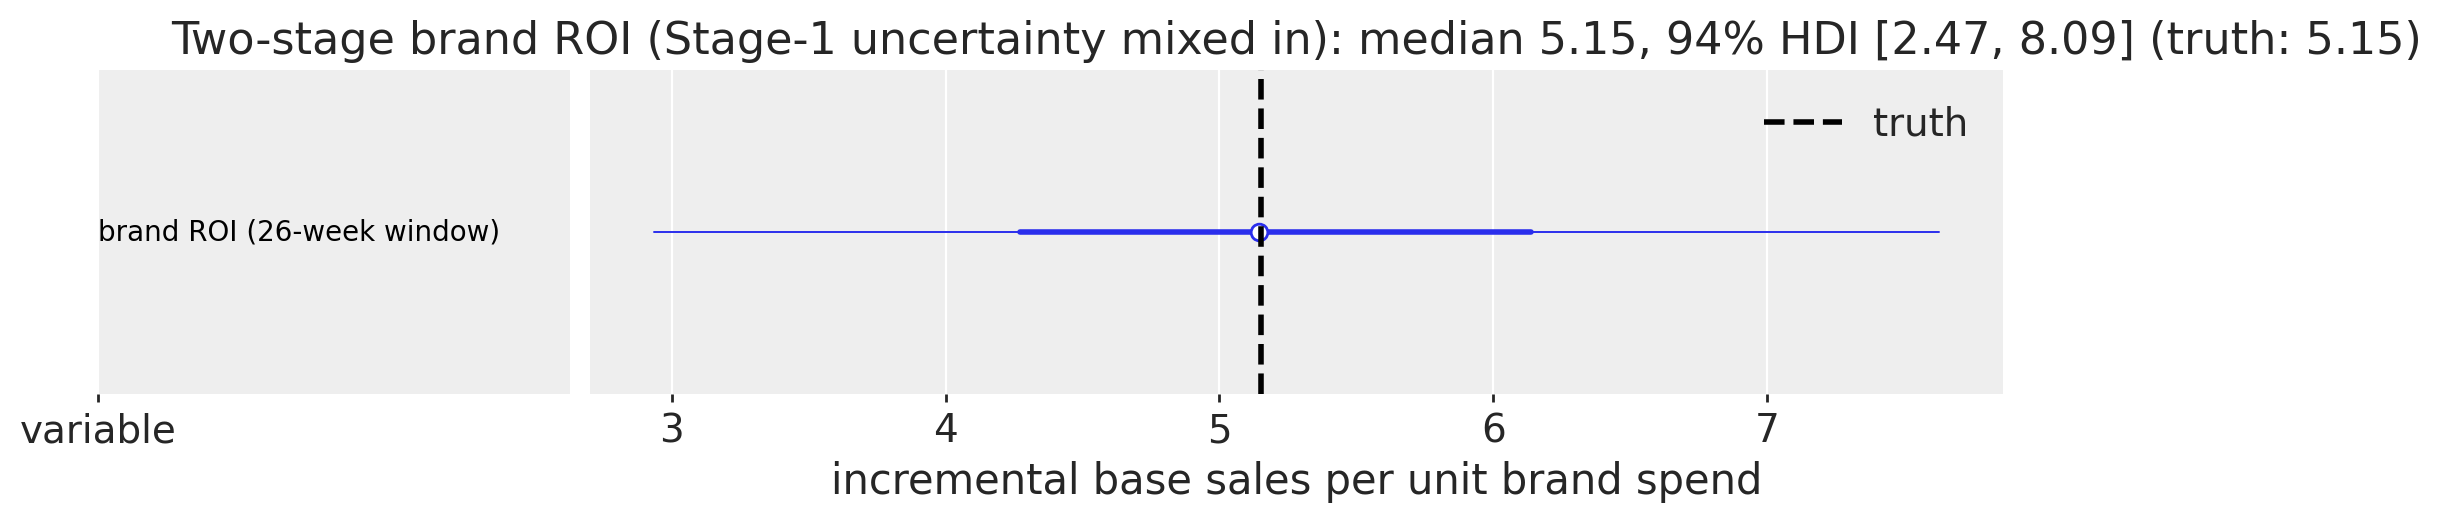

In [39]:
# Headline: the mixed posterior, which carries both Stage-1 and Stage-2 uncertainty.
roi_brand_draws = cum_multiplier_mixed.sel(
    response="baseline", exog="brand_spend", horizon=horizon
).drop_vars(["response", "exog", "horizon"])
roi_brand_median = float(roi_brand_draws.median())
roi_brand_hdi = az.hdi(roi_brand_draws, prob=0.94)

pc = az.plot_forest(
    xr.Dataset({f"brand ROI ({horizon}-week window)": roi_brand_draws}),
    combined=True,
    point_estimate="median",
    figure_kwargs={"figsize": (10, 2.5)},
)
ax = pc.viz["/"]["plot"].sel(column="forest").item()
ax.axvline(
    true_long_term_roi, color="black", linestyle="--", linewidth=2, label="truth"
)
ax.legend()
ax.set(
    title=(
        f"Two-stage brand ROI (Stage-1 uncertainty mixed in): "
        f"median {roi_brand_median:.2f}, "
        f"94% HDI [{float(roi_brand_hdi.sel(ci_bound='lower')):.2f}, "
        f"{float(roi_brand_hdi.sel(ci_bound='upper')):.2f}] "
        f"(truth: {true_long_term_roi:.2f})"
    ),
    xlabel="incremental base sales per unit brand spend",
);

For the second quantity we convolve the historical spend path with the per-horizon multiplier draws, which yields a full posterior distribution of the total in-sample uplift. Comparing it against the total brand spend (dashed line) answers the budget question directly: did the brand campaigns pay for themselves within the attribution window?

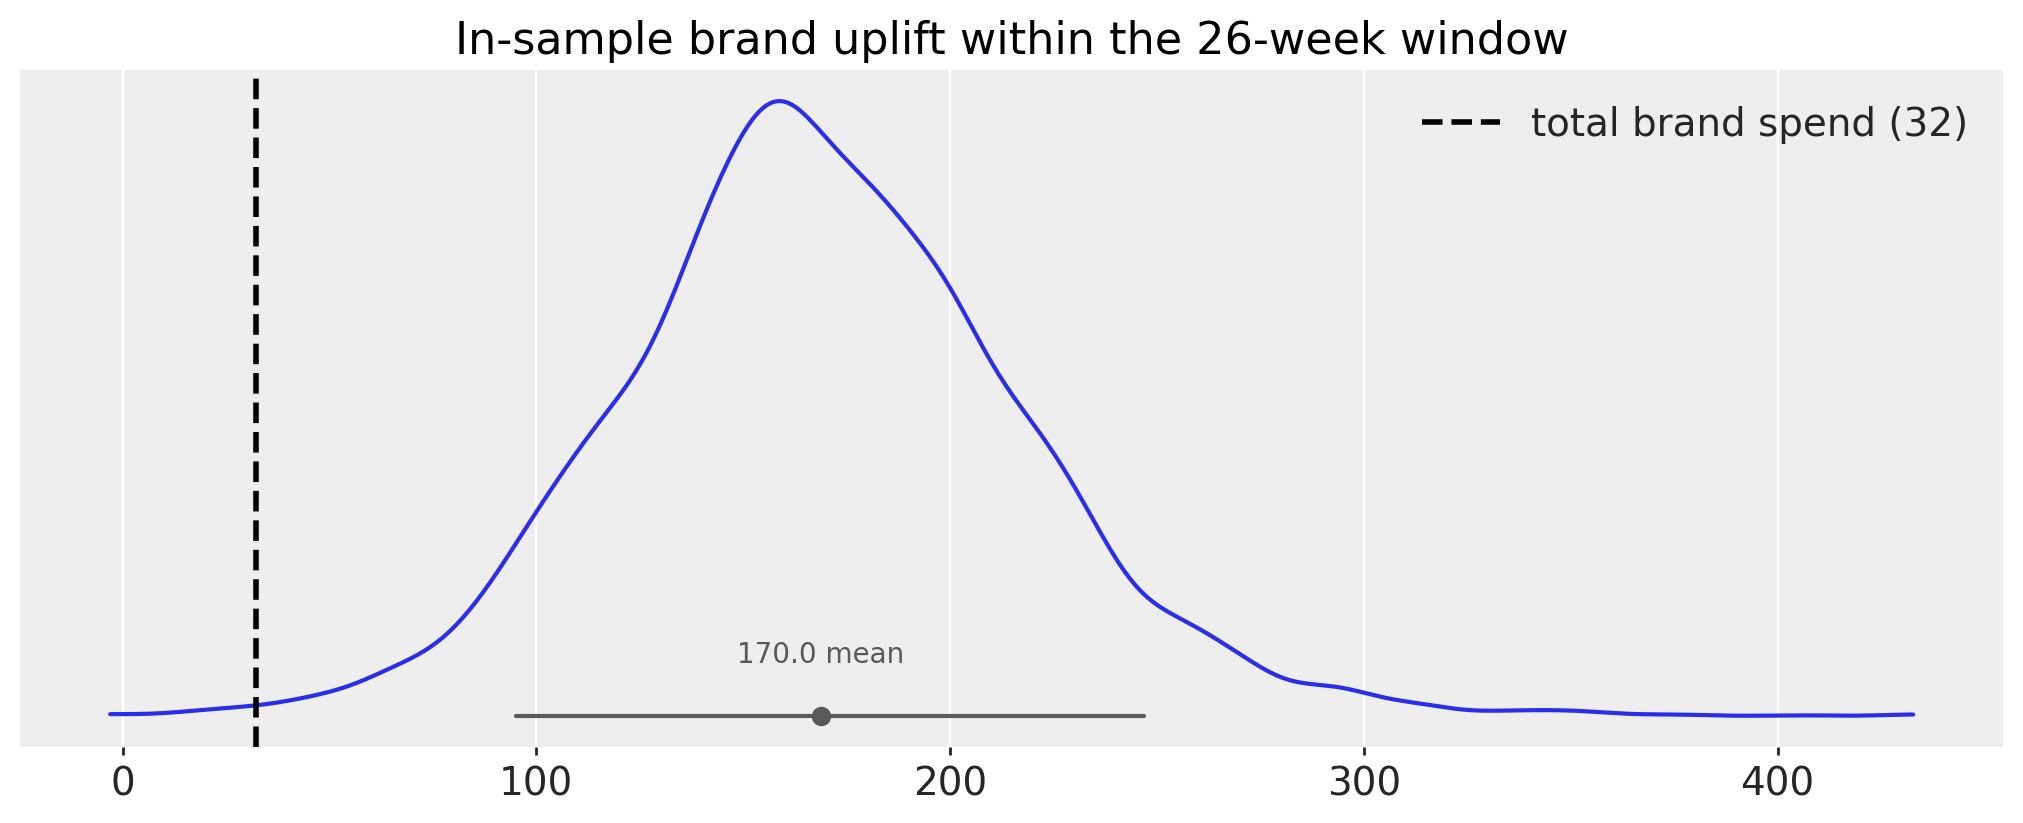

In [40]:
theta_base = theta_mixed.sel(response="baseline", exog="brand_spend").values

spend_path = df["brand_spend"].to_numpy()
brand_contribution_draws = np.zeros((*theta_base.shape[:2], n_obs))
for h in range(horizon + 1):
    brand_contribution_draws[:, :, h:] += (
        theta_base[:, :, h][:, :, None] * spend_path[None, None, : n_obs - h]
    )

brand_contribution = xr.DataArray(
    brand_contribution_draws,
    dims=("chain", "draw", "date"),
    coords={"date": df["date"]},
    name="brand_contribution",
)
brand_contribution_median = brand_contribution.median(dim=("chain", "draw"))

total_uplift_draws = brand_contribution.sum("date")
total_brand_uplift = float(total_uplift_draws.median())
total_brand_spend = float(spend_path.sum())

pc = az.plot_dist(
    xr.Dataset({"in-sample brand uplift ($10k)": total_uplift_draws}),
    figure_kwargs={"figsize": (10, 4)},
)
ax = pc.viz["plot"]["in-sample brand uplift ($10k)"].item()
ax.axvline(
    total_brand_spend,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"total brand spend ({total_brand_spend:.0f})",
)
ax.legend()
ax.set(title=f"In-sample brand uplift within the {horizon}-week window");

The punchline figure compares the two views of ROI for every spend line, with the true values as black diamonds. Each diamond sits at the *estimand of its own row*: for the performance channels both models target the same short-term ROI, so their diamonds line up and both intervals cover them. For brand the two rows answer different questions — the naive row estimates the direct short-term effect (true value zero, marked on the naive row) while the two-stage row estimates the 26-week dynamic multiplier (true value `true_long_term_roi`, marked on the two-stage row). Marking each row against its own truth avoids the misleading impression that the naive model is badly estimating the long-term effect it never set out to measure.

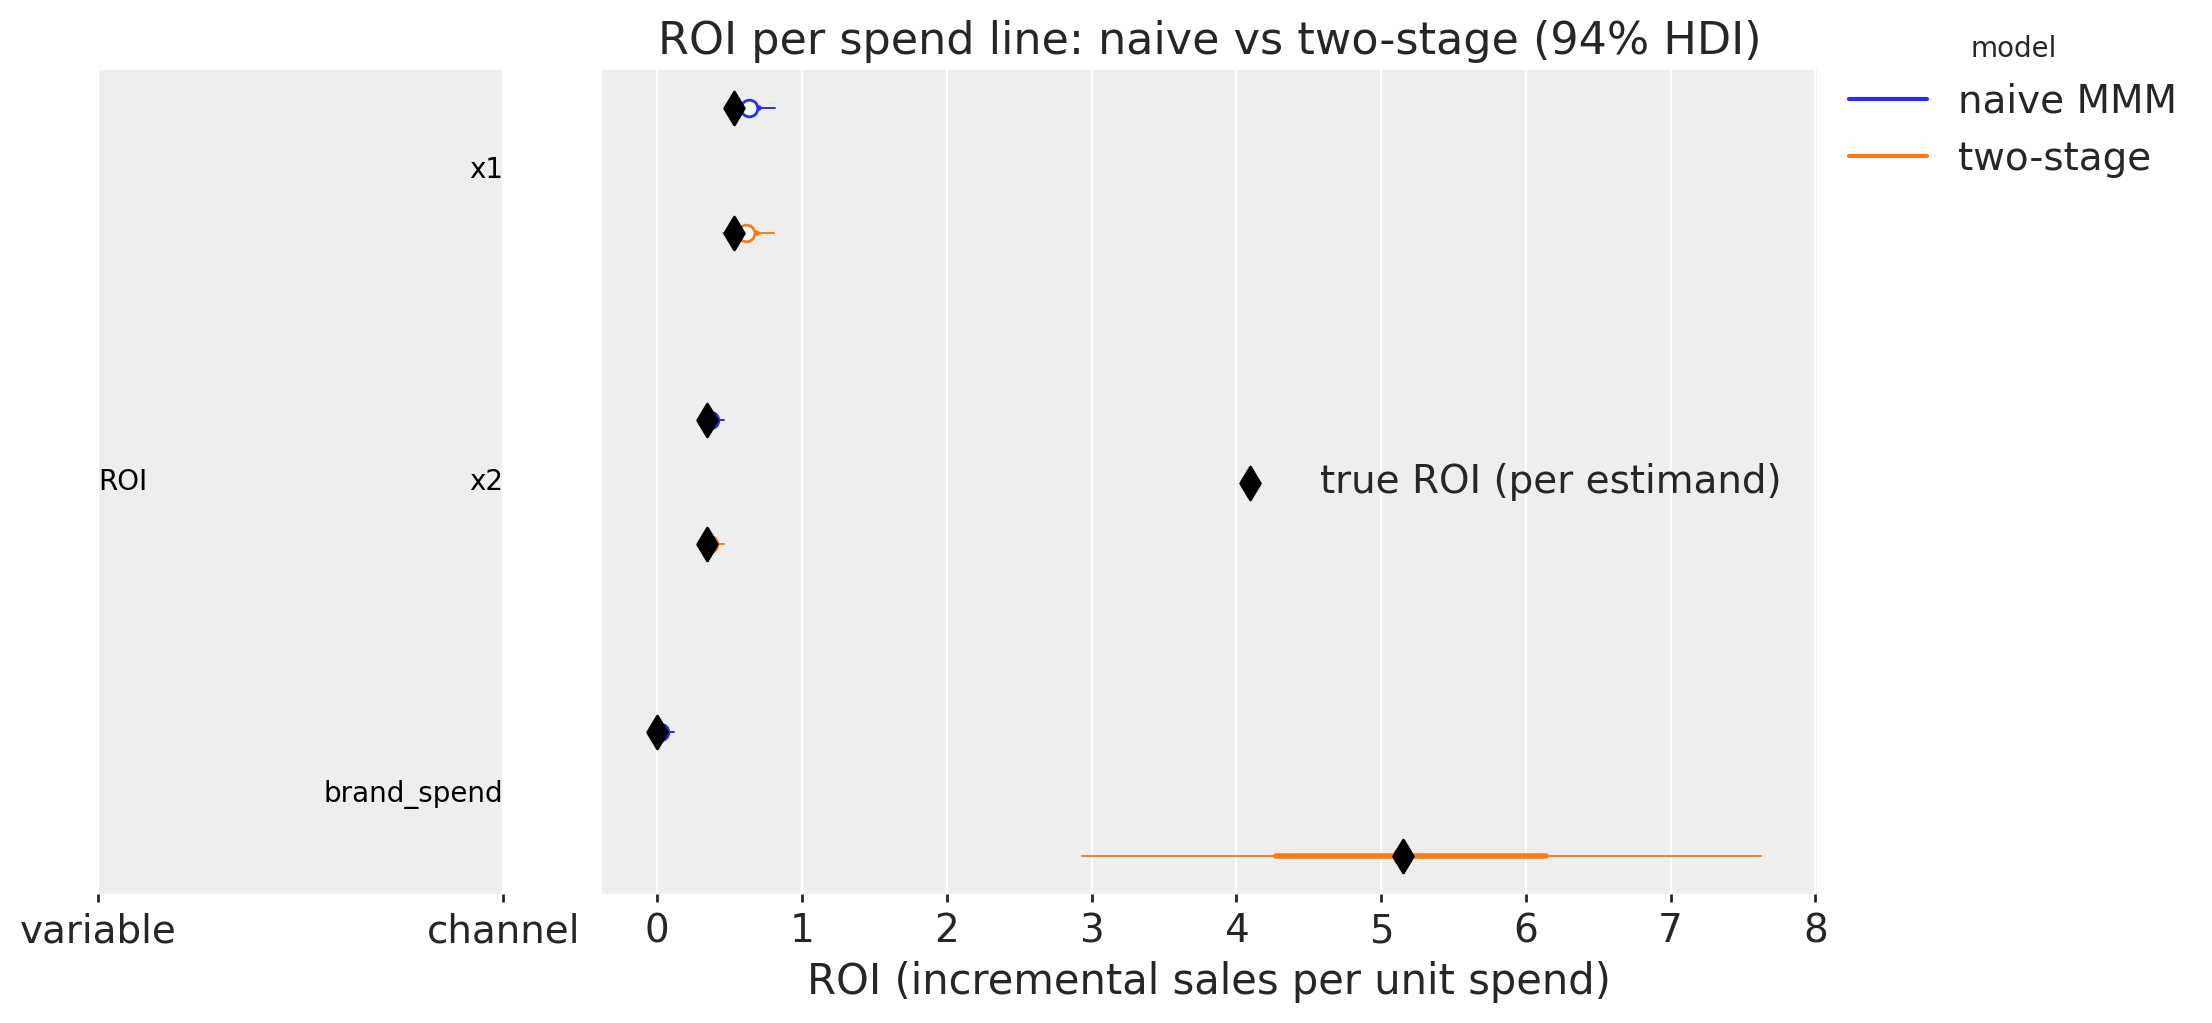

In [41]:
roi_two_stage = xr.concat(
    [roi_stage1, roi_brand_draws.expand_dims(channel=["brand_spend"])],
    dim="channel",
)
roi_compare = xr.concat([roi_naive, roi_two_stage], dim="model").assign_coords(
    model=["naive MMM", "two-stage"]
)
dt = xr.DataTree.from_dict(
    {"/posterior": xr.DataTree(xr.Dataset({"ROI": roi_compare}))}
)

pc = az.plot_forest(
    dt, combined=True, point_estimate="median", figure_kwargs={"figsize": (11, 5)}
)
pc.add_legend("model")
ax = pc.viz["/"]["plot"].sel(column="forest").item()
# The two models estimate different estimands for brand: the naive model targets
# the direct short-term effect (true value 0), the two-stage model the 26-week
# multiplier (true value `true_long_term_roi`). For the performance channels both
# models target the same short-term ROI. So we mark a truth diamond per (channel,
# model) at that model's own estimand rather than one shared diamond per row.
true_roi_by_model = {
    "x1": {"naive MMM": true_roi_x1, "two-stage": true_roi_x1},
    "x2": {"naive MMM": true_roi_x2, "two-stage": true_roi_x2},
    "brand_spend": {"naive MMM": 0.0, "two-stage": true_long_term_roi},
}
first_diamond = True
for channel in naive_channels:
    pe = pc.viz["point_estimate"]["ROI"].sel(channel=channel)
    for model in roi_compare["model"].values:
        y_pos = pe.sel(model=model).item().get_offsets()[0, 1]
        ax.scatter(
            true_roi_by_model[channel][model],
            y_pos,
            color="black",
            marker="d",
            s=70,
            zorder=5,
            label="true ROI (per estimand)" if first_diamond else None,
        )
        first_diamond = False
ax.legend(loc="center right")
ax.set(
    title="ROI per spend line: naive vs two-stage (94% HDI)",
    xlabel="ROI (incremental sales per unit spend)",
);

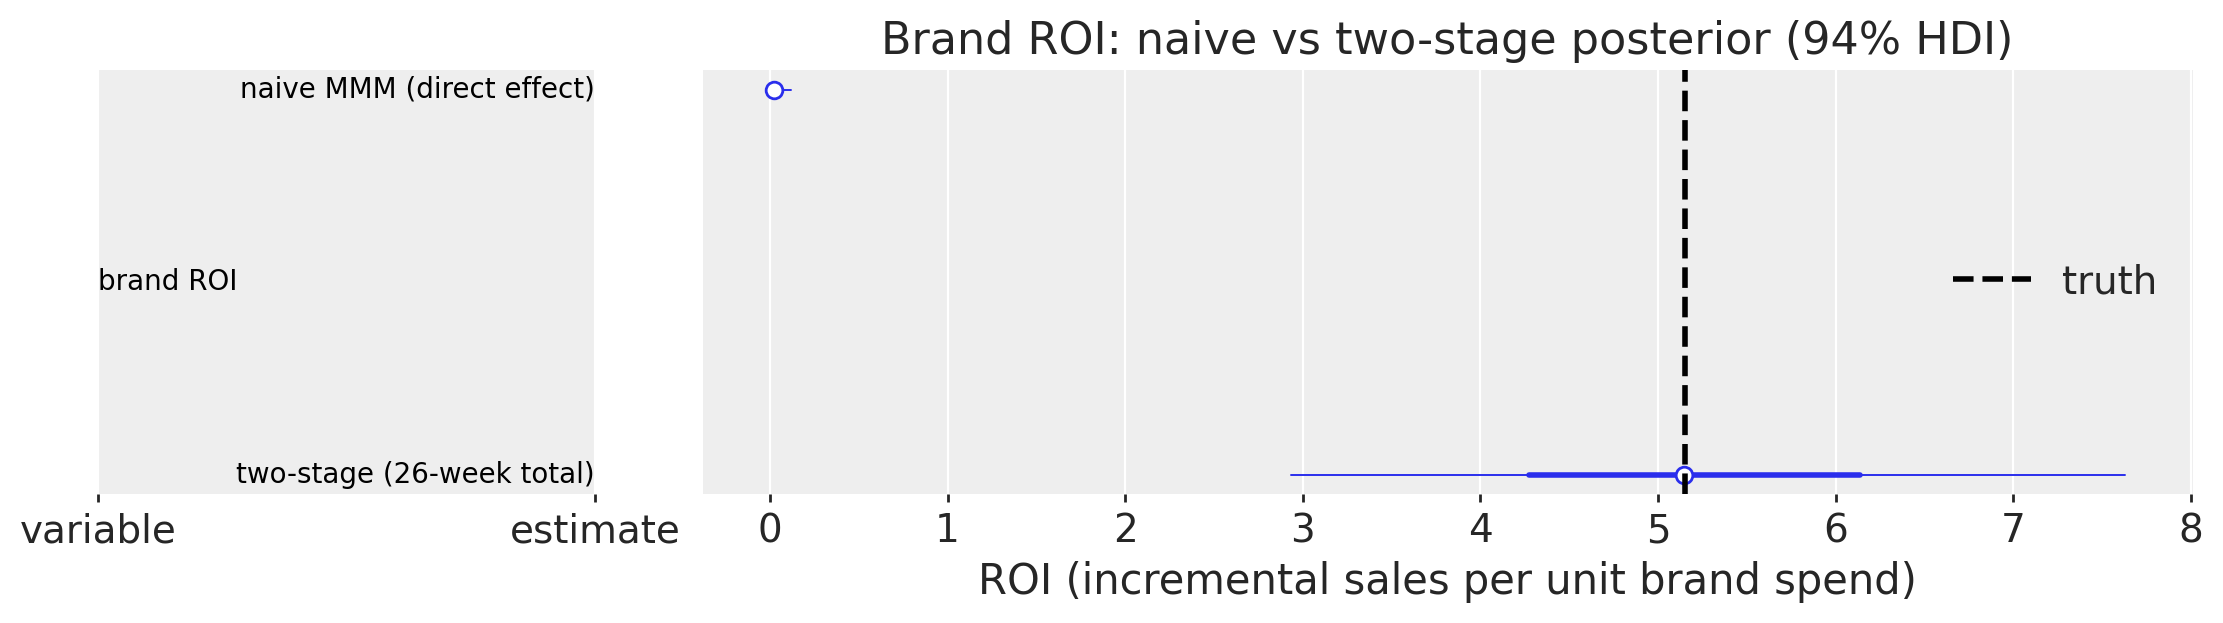

In [42]:
naive_brand_draws = roi_naive.sel(channel="brand_spend").drop_vars("channel")

brand_roi_compare = xr.concat(
    [naive_brand_draws, roi_brand_draws], dim="estimate"
).assign_coords(estimate=["naive MMM (direct effect)", "two-stage (26-week total)"])

pc = az.plot_forest(
    xr.Dataset({"brand ROI": brand_roi_compare}),
    combined=True,
    point_estimate="median",
    figure_kwargs={"figsize": (11, 3)},
)
ax = pc.viz["/"]["plot"].sel(column="forest").item()
ax.axvline(
    true_long_term_roi, color="black", linestyle="--", linewidth=2, label="truth"
)
ax.legend(loc="center right")
ax.set(
    title="Brand ROI: naive vs two-stage posterior (94% HDI)",
    xlabel="ROI (incremental sales per unit brand spend)",
);

Finally, the in-sample decomposition. We stack the steady baseline (the extracted baseline minus the brand-driven part), the brand uplift, and the short-term channel contributions; the remaining gap to observed sales is seasonality plus noise. This is a *median* decomposition: each band is a per-variable posterior median, so the components are a readable visual summary rather than a draw-wise additive breakdown (medians of parts do not sum to the median of the whole).

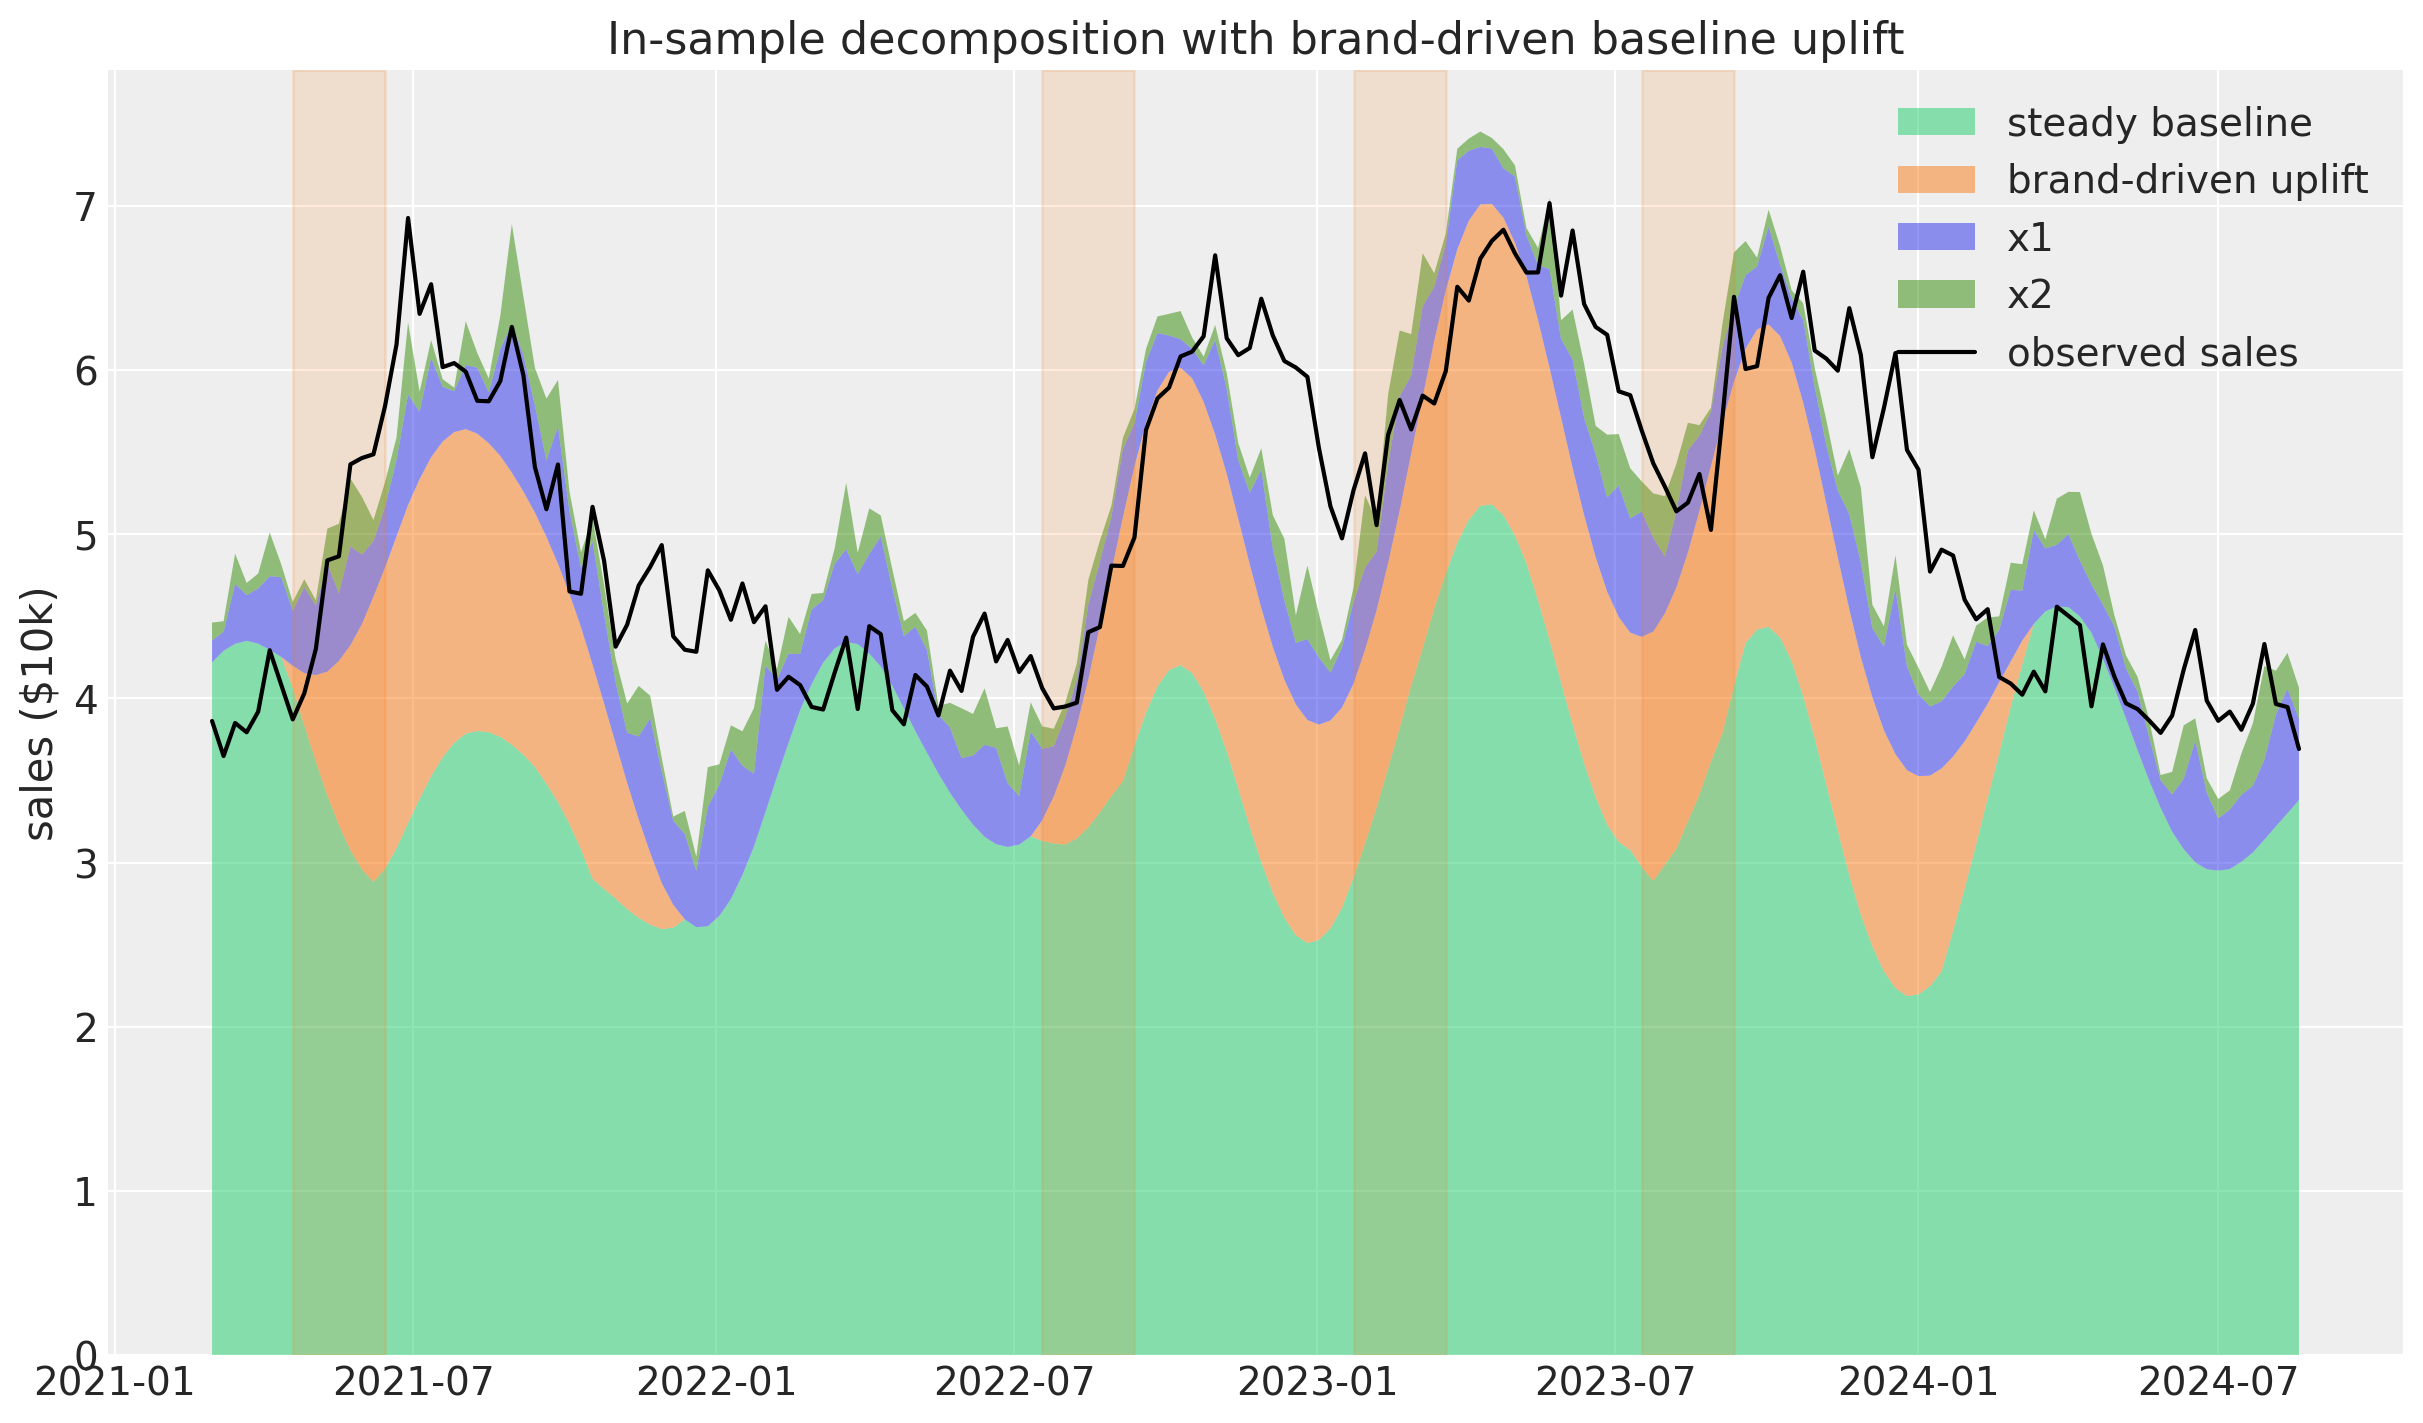

In [43]:
channel_contribution_median = (
    mmm.idata.posterior["channel_contribution_original_scale"]
    .median(dim=("chain", "draw"))
    .to_numpy()
)
steady_baseline = baseline_median.to_numpy() - brand_contribution_median.to_numpy()

components = np.vstack(
    [
        steady_baseline,
        brand_contribution_median.to_numpy(),
        channel_contribution_median[:, 0],
        channel_contribution_median[:, 1],
    ]
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.stackplot(
    df["date"],
    components,
    labels=["steady baseline", "brand-driven uplift", "x1", "x2"],
    colors=["C7", "C1", "C0", "C2"],
    alpha=0.5,
)
ax.plot(df["date"], df["y"], color="black", linewidth=1.5, label="observed sales")
shade_flights(ax)
ax.legend(loc="upper right")
ax.set(
    title="In-sample decomposition with brand-driven baseline uplift",
    ylabel="sales ($10k)",
);

```{admonition} Reading the two ROI columns
:class: tip
The naive and two-stage columns answer *different questions*. The naive number is the direct short-term effect, and for brand media it is honestly close to zero. The two-stage number is the total effect transmitted through the funnel over 26 weeks. The failure mode in practice is not computing the naive number, it is *misreading* it as the total effect and cutting the brand budget accordingly.
```

## Pitfall Made Concrete: Plug-In vs Mixed Uncertainty

The headline interval already carries Stage-1 uncertainty, because we built it by mixing VARX refits across baseline draws. It is worth seeing explicitly what the shortcut would have cost. The *plug-in* multiplier from earlier — conditioned on the single median baseline — ignores Stage-1 estimation error, so its credible interval is narrower than an honest one. Below we put the two intervals side by side, and then trace the individual baseline-draw refits to show exactly where the extra width comes from.

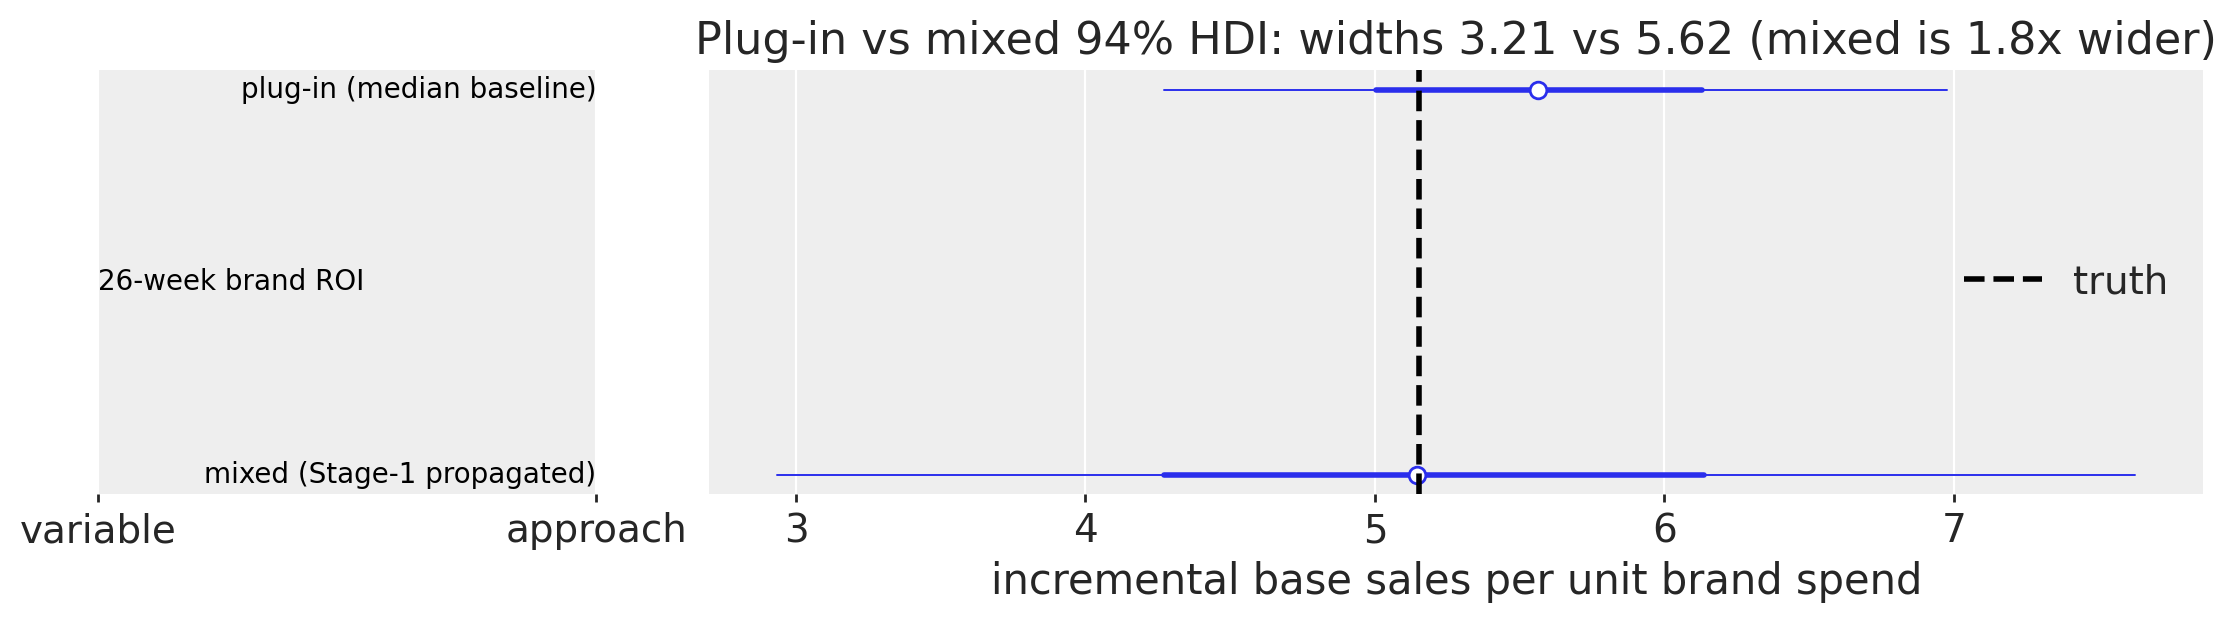

In [44]:
# Both posteriors are already computed (no refitting needed here): the plug-in
# from the single median-baseline fit, the mixed from the baseline-draw refits.
roi_brand_plugin = (
    cum_multiplier_plugin.sel(response="baseline", exog="brand_spend", horizon=horizon)
    .drop_vars(["response", "exog", "horizon"])
    .assign_coords(chain=np.arange(4), draw=np.arange(1_000))
)
plugin_hdi = az.hdi(roi_brand_plugin, prob=0.94)

roi_uncertainty = xr.concat(
    [roi_brand_plugin, roi_brand_draws], dim="approach"
).assign_coords(approach=["plug-in (median baseline)", "mixed (Stage-1 propagated)"])

pc = az.plot_forest(
    xr.Dataset({"26-week brand ROI": roi_uncertainty}),
    combined=True,
    point_estimate="median",
    figure_kwargs={"figsize": (11, 3)},
)
ax = pc.viz["/"]["plot"].sel(column="forest").item()
ax.axvline(
    true_long_term_roi, color="black", linestyle="--", linewidth=2, label="truth"
)
ax.legend(loc="center right")
plugin_width = float(
    plugin_hdi.sel(ci_bound="upper") - plugin_hdi.sel(ci_bound="lower")
)
mixed_width = float(
    roi_brand_hdi.sel(ci_bound="upper") - roi_brand_hdi.sel(ci_bound="lower")
)
ax.set(
    title=(
        f"Plug-in vs mixed 94% HDI: widths {plugin_width:.2f} vs {mixed_width:.2f} "
        f"(mixed is {mixed_width / plugin_width:.1f}x wider)"
    ),
    xlabel="incremental base sales per unit brand spend",
);

The figure below traces where the extra width comes from. It overlays the plug-in cumulative-multiplier band (median line and 94% HDI, conditioned on the median Stage-1 baseline), the mixed band (Stage-1 uncertainty propagated), the median multiplier curves from each individual baseline-draw refit, and the true curve. The per-refit medians fan out beyond the narrow plug-in band and fill the wider mixed band: that fan *is* the Stage-1 contribution to uncertainty, and it is exactly what the plug-in interval leaves out.

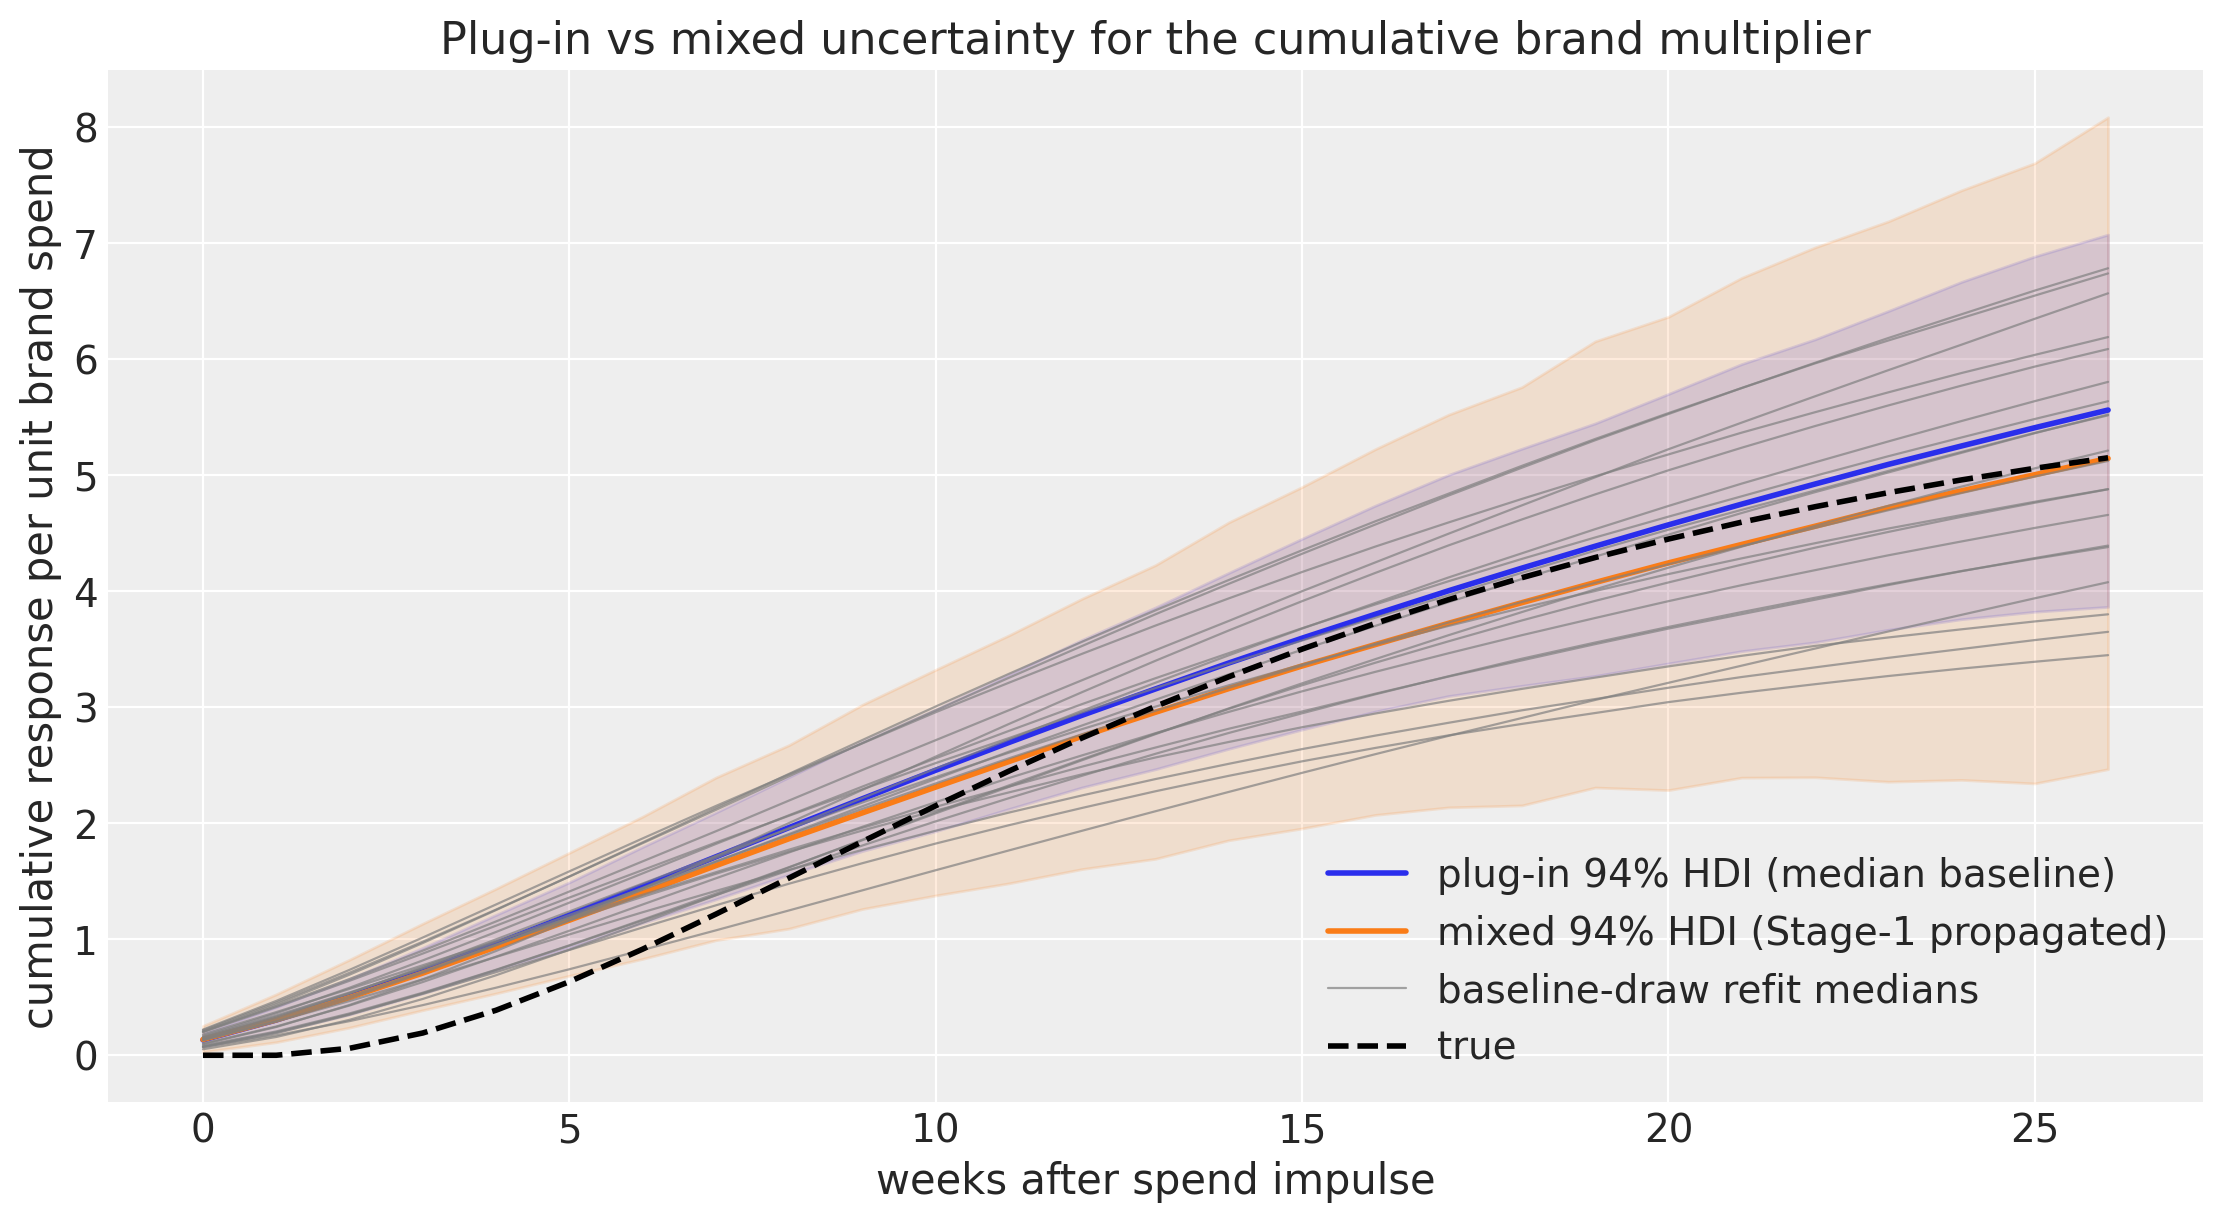

In [45]:
plugin_curve = cum_multiplier_plugin.sel(response="baseline", exog="brand_spend")
mixed_curve = cum_multiplier_mixed.sel(response="baseline", exog="brand_spend")
plugin_band = az.hdi(plugin_curve, prob=0.94)
mixed_band = az.hdi(mixed_curve, prob=0.94)

fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(
    plugin_curve["horizon"],
    plugin_band.sel(ci_bound="lower"),
    plugin_band.sel(ci_bound="upper"),
    alpha=0.15,
    color="C0",
)
ax.plot(
    plugin_curve["horizon"],
    plugin_curve.median(dim=("chain", "draw")),
    color="C0",
    linewidth=2,
    label="plug-in 94% HDI (median baseline)",
)
ax.fill_between(
    mixed_curve["horizon"],
    mixed_band.sel(ci_bound="lower"),
    mixed_band.sel(ci_bound="upper"),
    alpha=0.15,
    color="C1",
)
ax.plot(
    mixed_curve["horizon"],
    mixed_curve.median(dim=("chain", "draw")),
    color="C1",
    linewidth=2,
    label="mixed 94% HDI (Stage-1 propagated)",
)
for i, curve in sensitivity_curves.items():
    ax.plot(
        curve["horizon"],
        curve,
        color="0.5",
        linewidth=0.8,
        alpha=0.7,
        label="baseline-draw refit medians" if i == 0 else None,
    )
ax.plot(
    np.arange(horizon + 1),
    true_curves["baseline"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="true",
)
ax.legend(loc="lower right")
ax.set(
    title="Plug-in vs mixed uncertainty for the cumulative brand multiplier",
    xlabel="weeks after spend impulse",
    ylabel="cumulative response per unit brand spend",
);

The comparison makes the cost of the shortcut concrete: the plug-in band is materially narrower than the mixed band, and the individual baseline-draw refit medians fan out across the mixed band rather than sitting inside the plug-in one. The qualitative conclusion is unchanged — a large, positive long-run brand multiplier near the truth — but the honest headline is the wider *mixed* interval we reported, and quoting the plug-in interval instead would overstate precision by ignoring Stage-1 error. When even the mixed interval is not enough (heavier Stage-1 uncertainty, or feedback between the stages), the next step is a joint model in which the funnel equations and the MMM are estimated together (see {ref}`mmm_funnel_mueffect` for a step in that direction).

## Assumptions, Caveats, and Extensions

- **Mediation completeness.** The workflow credits brand only through the measured mindset metrics and the baseline. If brand marketing works through additional unmeasured paths, the total effect is underestimated. Choose tracking metrics that cover the funnel your category actually has.
- **Exogeneity of brand spend.** The causal reading of the dynamic multiplier requires that flights do not respond to weekly demand or awareness shocks. Annual planning calendars usually satisfy this; performance-triggered brand boosts would not, and would require identification arguments beyond this notebook.
- **The baseline is a residual.** Anything omitted from Stage 1 (price, distribution, promotions, competitor actions) lands in the baseline. If such a driver correlates with the flight calendar, the VARX will misattribute it to brand. Include known drivers as controls in Stage 1 or as variables in Stage 2.
- **Unit roots and cointegration.** With genuinely integrated series, the levels VAR should be replaced (or at least cross-checked) with a VECM as in Cain (2022). The stationarity checks of the Stage-2 preparation section are the guardrail.
- **Calibration.** Brand lift studies (search or survey lift) can anchor the spend-to-awareness link, in the same spirit as the sales lift tests of {ref}`mmm_lift_test`.

### Key Takeaways

1. A standard MMM estimates the *direct short-term* effect of brand media, which is typically near zero. That number is correct and, on its own, misleading.
2. A time-varying intercept turns the MMM baseline from a nuisance into a measurable quantity that contains the accumulated brand effect.
3. A Bayesian VARX on {baseline, brand metrics} with brand spend exogenous recovers the long-run transmission with full posterior uncertainty, and needs no structural identification for the planner-set spend input.
4. Report the horizon convention explicitly, and never multiply total historical spend by a truncated multiplier to decompose in-sample sales: convolve the spend path instead.
5. Two-stage inference understates uncertainty if you plug in a Stage-1 point estimate; propagate it by mixing VARX refits across Stage-1 baseline draws (as the headline here does) and report that wider interval.

### References

- Cain, P. M. (2022). "Modelling short- and long-term marketing effects in the consumer purchase journey." *International Journal of Research in Marketing*, 39(1), 96-116.
- O'Sullivan, R. (2025). [Capturing the long-term causal effect of brand marketing](https://medium.com/@raz1470/capturing-the-long-term-causal-effect-of-brand-marketing-bc577621a627).
- Oulton, N. / 1749.io. [Measuring Marketing Effectiveness Over the Long-Term](https://1749.io/learn/f/measuring-marketing-effectiveness-over-the-long-term).
- Dekimpe, M. G., & Hanssens, D. M. (1999). "Sustained spending and persistent response: A new look at long-term marketing profitability." *Journal of Marketing Research*, 36(4), 397-412.

In [46]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,impulso

Last updated: Mon, 03 Aug 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
impulso       : 0.0.10

arviz         : 1.2.0
graphviz      : 0.21
impulso       : 0.0.10
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
xarray        : 2026.4.0

Watermark: 2.6.0

